# **Project Name**    -

FBI


##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual/Team
##### **Team Member 1 -**
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [86]:
# Import Libraries

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns',1000)

import missingno as mng
from scipy.stats import chi2
import folium
import scipy.stats as stats
from scipy.stats import chi2_contingency
from scipy.stats import kruskal
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, balanced_accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier

<IPython.core.display.Javascript object>

### Dataset Loading

In [2]:
# Load Dataset

data = pd.read_excel("Train.xlsx")

<IPython.core.display.Javascript object>

### Dataset First View

In [3]:
# Dataset First Look

data.sample(5)

,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
155755,Other Theft,56XX VICTORIA DR,Kensington-Cedar Cottage,495228.06,5453412.77,49.233476,-123.065549,21.0,59.0,2002,4,5,2002-04-05
101921,Other Theft,6XX W 41ST AVE,Oakridge,491372.94,5453422.83,49.233524,-123.118504,19.0,9.0,2001,9,16,2001-09-16
275873,Break and Enter Residential/Other,14XX W 14TH AVE,Fairview,490055.36,5456239.31,49.258839,-123.136672,18.0,21.0,2005,9,28,2005-09-28
159014,Theft from Vehicle,10XX ROBSON ST,West End,491058.23,5458959.00,49.283318,-123.122950,12.0,41.0,2002,5,4,2002-05-04
184091,Vehicle Collision or Pedestrian Struck (with I...,21XX BLOCK SE MARINE DR,Victoria-Fraserview,495340.00,5450684.00,49.208931,-123.063979,6.0,22.0,2002,12,15,2002-12-15


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count

print(f"The dataset has {data.shape[1]} columns and {data.shape[0]} rows")

The dataset has 13 columns and 474565 rows


### Dataset Information

In [5]:
# Dataset Info

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474565 entries, 0 to 474564
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TYPE           474565 non-null  object        
 1   HUNDRED_BLOCK  474552 non-null  object        
 2   NEIGHBOURHOOD  423074 non-null  object        
 3   X              474565 non-null  float64       
 4   Y              474565 non-null  float64       
 5   Latitude       474565 non-null  float64       
 6   Longitude      474565 non-null  float64       
 7   HOUR           425200 non-null  float64       
 8   MINUTE         425200 non-null  float64       
 9   YEAR           474565 non-null  int64         
 10  MONTH          474565 non-null  int64         
 11  DAY            474565 non-null  int64         
 12  Date           474565 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6), int64(3), object(3)
memory usage: 47.1+ MB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count

data.duplicated().sum()

44618

#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count

missing_data = data.isnull().sum()
missing_percent = (missing_data / len(data)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_data, 'Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)
missing_df

<IPython.core.display.Javascript object>

,Missing Values,Percentage
NEIGHBOURHOOD,51491,10.850147
HOUR,49365,10.402158
MINUTE,49365,10.402158
HUNDRED_BLOCK,13,0.002739


<IPython.core.display.Javascript object>

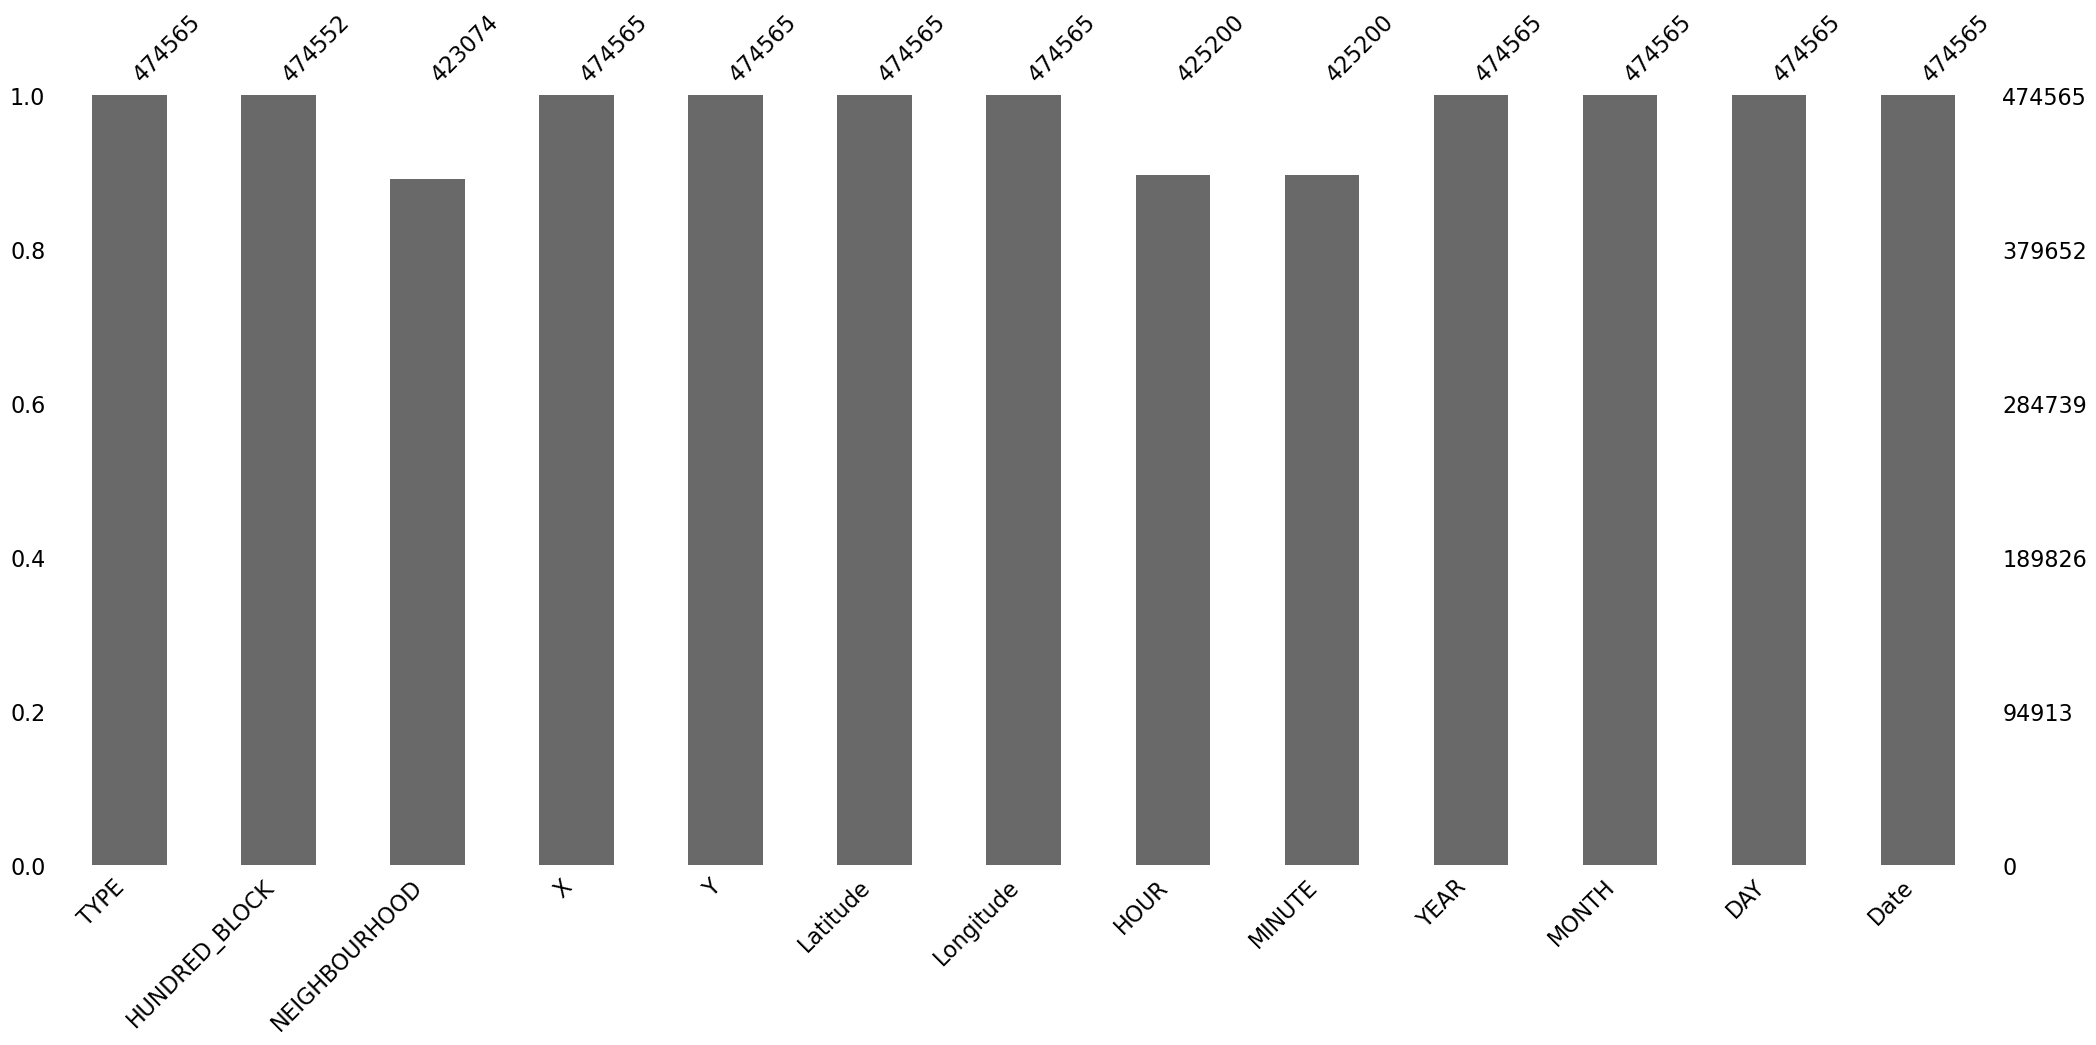

In [8]:
# Visualizing the missing values

mng.bar(data)
plt.show()

### What did you know about your dataset?

From my analysis of the dataset, I have identified key insights regarding its structure, completeness, and potential issues that need to be addressed before moving forward with time series analysis.

The dataset consists of 474,565 rows and 13 columns, capturing various details about crimes, including the type of crime, location, time, and date. The "Date" column is already in the correct datetime format, which is essential for time series analysis.

Missing Values & Data Completeness
There are missing values in key columns:

NEIGHBOURHOOD: 51,491 missing values (~10.85%)

HOUR & MINUTE: 49,365 missing values (~10.4%)

HUNDRED_BLOCK: 13 missing values (Negligible, ~0.0027%)

The missing timestamps (HOUR, MINUTE) could significantly affect time-based analysis, and the NEIGHBOURHOOD column missing over 10% of data may impact location-based insights. Strategies for handling these missing values need careful consideration, such as imputation or dropping rows.

Duplicates
There are 44,618 duplicate rows, which suggests redundant data that might skew analysis results. These duplicates should be carefully reviewed and possibly removed, ensuring only unique records are used for analysis.

Data Types & Readiness
The dataset has the correct data types for most columns:

Categorical columns (TYPE, NEIGHBOURHOOD, HUNDRED_BLOCK) are stored as objects.

Numeric columns (X, Y, Latitude, Longitude, HOUR, MINUTE, YEAR, MONTH, DAY) are stored as floats or integers.

"Date" is already in datetime64, which is a positive sign for time-based analysis.

Business Impact : 

Understanding this dataset is crucial for identifying crime trends and making data-driven decisions. 

The missing timestamps may cause gaps in time-series predictions, and duplicates might distort crime frequency analysis.

Before proceeding with visualization and modeling, I must address these issues through data cleaning, imputation, and outlier handling.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns

data.columns

Index(['TYPE', 'HUNDRED_BLOCK', 'NEIGHBOURHOOD', 'X', 'Y', 'Latitude',
       'Longitude', 'HOUR', 'MINUTE', 'YEAR', 'MONTH', 'DAY', 'Date'],
      dtype='object')

In [10]:
# Dataset Describe

data.describe().T

,count,mean,min,25%,50%,75%,max,std
X,474565.0,441028.01822,0.0,489916.53,491477.85,493610.19,511303.0,150295.319332
Y,474565.0,4889022.851684,0.0,5453572.36,5456819.64,5458622.34,5512579.0,1665850.060645
Latitude,474565.0,44.138029,0.0,49.234871,49.264051,49.2803,49.755314,15.039271
Longitude,474565.0,-110.301025,-124.549757,-123.127383,-123.107058,-123.065646,0.0,37.583147
HOUR,425200.0,13.721263,0.0,9.0,15.0,19.0,23.0,6.785751
MINUTE,425200.0,16.736047,0.0,0.0,10.0,30.0,59.0,18.354675
YEAR,474565.0,2004.363632,1999.0,2001.0,2004.0,2008.0,2011.0,3.850689
MONTH,474565.0,6.5557,1.0,4.0,7.0,9.0,12.0,3.408676
DAY,474565.0,15.439253,1.0,8.0,15.0,23.0,31.0,8.759352
Date,474565,2004-11-11 23:51:07.470209792,1999-01-01 00:00:00,2001-06-06 00:00:00,2004-05-18 00:00:00,2008-03-27 00:00:00,2011-12-31 00:00:00,NaN


### Variables Description

The dataset consists of 13 columns, each representing different attributes of reported crimes. Below is a detailed description of each variable:

TYPE (Categorical - Object)

Description: Represents the category of crime (e.g., "Theft from Vehicle," "Break and Enter").

Importance: Helps in crime trend analysis and understanding which crimes are most prevalent.

HUNDRED_BLOCK (Categorical - Object)

Description: Provides the approximate block location where the crime occurred (e.g., "11XX ALBERNI ST").

Importance: Useful for analyzing crime hotspots.

NEIGHBOURHOOD (Categorical - Object, Some Missing Values: ~10.85%)

Description: Specifies the neighborhood where the crime took place.

Importance: Key for geospatial crime analysis, identifying high-crime neighborhoods.

X & Y (Numerical - Float64)

Description: Coordinates representing the crime location in a projected coordinate system (Easting/Northing).

Importance: Used for mapping crimes geographically but may need conversion to latitude/longitude for better analysis.

Latitude & Longitude (Numerical - Float64)

Description: Geographic coordinates of the crime location.

Importance: Essential for geospatial visualizations such as heatmaps.

HOUR & MINUTE (Numerical - Float64, Some Missing Values: ~10.4%)

Description: Represents the exact time when the crime was reported.

Importance: Critical for time-based crime analysis (e.g., identifying peak crime hours).

YEAR, MONTH, DAY (Numerical - Int64)

Description: Breakdown of the crime’s occurrence date into year, month, and day.

Importance: Helps in seasonal trend analysis and time-series modeling.

DATE (Datetime - datetime64)

Description: The full date when the crime occurred.

Importance: Essential for time-series forecasting and crime trend analysis.

Business Impact
Understanding each variable helps in preparing the dataset for further analysis, ensuring accurate visualizations and predictions. Missing values in NEIGHBOURHOOD, HOUR, and MINUTE could lead to incomplete insights, and handling them properly is a priority before moving forward.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.

unique_values = data.nunique().sort_values(ascending=False)
unique_values_df = pd.DataFrame({'Column': unique_values.index, 'Unique Values': unique_values.values})

unique_values_df

<IPython.core.display.Javascript object>

,Column,Unique Values
0,Latitude,89488
1,Longitude,87190
2,X,84225
3,Y,82768
4,HUNDRED_BLOCK,20566
5,Date,4748
6,MINUTE,60
7,DAY,31
8,NEIGHBOURHOOD,24
9,HOUR,24


Understanding the number of unique values in each column helps me determine data variability, possible redundancies, and key factors affecting analysis. Here’s what I have learned:

Latitude (89,488) & Longitude (87,190)

Despite having 474,565 rows, there are only ~89k unique latitude values and ~87k unique longitude values.
This suggests that multiple crimes occurred at the same locations multiple times, making geospatial crime clustering a viable analysis method.

X (84,225) & Y (82,768)

These are coordinate system values, slightly fewer unique values than latitude/longitude, possibly due to rounding or coordinate transformation.

HUNDRED_BLOCK (20,566 Unique Values)

This indicates crime locations are often repeated at the block level. Crime hotspots can be identified by analyzing the most frequently occurring blocks.

Date (4,748 Unique Values)

Since the dataset covers 13 years, this suggests crime data is recorded for nearly every day. This makes it suitable for time-series forecasting to detect patterns over time.

MINUTE (60) & HOUR (24)

Crime data captures every minute and hour of the day, making hourly crime trend analysis possible.

DAY (31), MONTH (12), YEAR (13)

Represents daily, monthly, and yearly variations in crime patterns. The dataset covers 13 years, meaning long-term crime trends can be analyzed.

NEIGHBOURHOOD (24 Unique Values)

There are 24 distinct neighborhoods where crimes have been reported. This allows for comparative crime rate analysis between neighborhoods.

TYPE (9 Unique Values)

Crimes are categorized into 9 distinct types, meaning the dataset is limited in crime variety but can still provide insights into which crime types are most common.

Business Impact
This analysis confirms that the dataset is rich in geospatial and time-series information, making it useful for identifying crime patterns, peak crime hours, high-crime locations, and seasonality trends. The next step involves data wrangling, where I will clean missing values and remove duplicates to ensure accurate results.

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
def little_mcar_test(df):
    """Performs Little's MCAR test on the dataset."""
    df = data.copy()
    
    # Select only numeric columns (MCAR test works only on numerical data)
    df_numeric = df.select_dtypes(include=[np.number])

    # Create a binary missing indicator matrix
    missing_mask = df_numeric.isnull().astype(int)
    
    # Compute row and column means
    row_means = missing_mask.mean(axis=1)
    col_means = missing_mask.mean(axis=0)
    
    # Compute expected frequency of missing values
    expected = np.outer(row_means, col_means)
    
    # Compute observed frequency of missing values
    observed = missing_mask.to_numpy()
    
    # Compute chi-square statistic
    chi_square_stat = ((observed - expected) ** 2 / expected).sum()
    
    # Degrees of freedom
    dof = (missing_mask.shape[0] - 1) * (missing_mask.shape[1] - 1)
    
    # Compute p-value
    p_value = 1 - chi2.cdf(chi_square_stat, dof)
    
    return chi_square_stat, p_value

# Run MCAR test
chi_square_stat, p_value = little_mcar_test(data)

# Interpretation
if p_value > 0.05:
    print("Missing data is MCAR (Missing Completely at Random).")
else:
    print("Missing data is NOT MCAR (There is a pattern in missing values).")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Missing data is NOT MCAR (There is a pattern in missing values).


In [13]:
for col in ['NEIGHBOURHOOD', 'TYPE']:
    missing_percentage = data.groupby(col)['HOUR'].apply(lambda x: x.isnull().mean() * 100)
    print(f"\nMissing HOUR % in different {col} groups:\n", missing_percentage)


Missing HOUR % in different NEIGHBOURHOOD groups:
 NEIGHBOURHOOD
Arbutus Ridge                0.0
Central Business District    0.0
Dunbar-Southlands            0.0
Fairview                     0.0
Grandview-Woodland           0.0
Hastings-Sunrise             0.0
Kensington-Cedar Cottage     0.0
Kerrisdale                   0.0
Killarney                    0.0
Kitsilano                    0.0
Marpole                      0.0
Mount Pleasant               0.0
Musqueam                     0.0
Oakridge                     0.0
Renfrew-Collingwood          0.0
Riley Park                   0.0
Shaughnessy                  0.0
South Cambie                 0.0
Stanley Park                 0.0
Strathcona                   0.0
Sunset                       0.0
Victoria-Fraserview          0.0
West End                     0.0
West Point Grey              0.0
Name: HOUR, dtype: float64

Missing HOUR % in different TYPE groups:
 TYPE
Break and Enter Commercial                                0.0
Break

In [14]:
for col in ['NEIGHBOURHOOD', 'TYPE']:
    missing_percentage = data.groupby(col)['HUNDRED_BLOCK'].apply(lambda x: x.isnull().mean() * 100)
    print(f"\nMissing HUNDRED BLOCK % in different {col} groups:\n", missing_percentage)


Missing HUNDRED BLOCK % in different NEIGHBOURHOOD groups:
 NEIGHBOURHOOD
Arbutus Ridge                0.000000
Central Business District    0.002080
Dunbar-Southlands            0.000000
Fairview                     0.000000
Grandview-Woodland           0.000000
Hastings-Sunrise             0.000000
Kensington-Cedar Cottage     0.000000
Kerrisdale                   0.000000
Killarney                    0.000000
Kitsilano                    0.004146
Marpole                      0.000000
Mount Pleasant               0.007441
Musqueam                     0.000000
Oakridge                     0.027697
Renfrew-Collingwood          0.000000
Riley Park                   0.008957
Shaughnessy                  0.000000
South Cambie                 0.000000
Stanley Park                 0.000000
Strathcona                   0.010940
Sunset                       0.006254
Victoria-Fraserview          0.010118
West End                     0.000000
West Point Grey              0.019004
Name: HUNDRED

### What all manipulations have you done and insights you found?

During data wrangling, we identified missing values in HOUR (10.4%), MINUTE (10.4%), NEIGHBOURHOOD (10.85%), and HUNDRED_BLOCK (0.0027%). Our analysis showed that missing values were not completely random (not MCAR) since HOUR was missing only for 'Offence Against a Person' (100%), indicating a clear pattern rather than randomness. This suggests that either these crimes aren't recorded with timestamps due to reporting constraints, or there is a purposeful omission, possibly due to privacy, legal, or investigative reasons. Additionally, HUNDRED_BLOCK had missing values varying across NEIGHBOURHOOD and TYPE, with Oakridge (2.77%) and West Point Grey (1.9%) having the highest percentage of missing values, suggesting geographic-based differences in reporting. Interestingly, NEIGHBOURHOOD had 0% missing HOUR values across all groups, confirming that neighborhood itself wasn't a contributing factor to missing time data. These findings indicate that missingness follows a structure, and we need to carefully decide the best imputation approach before moving forward.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

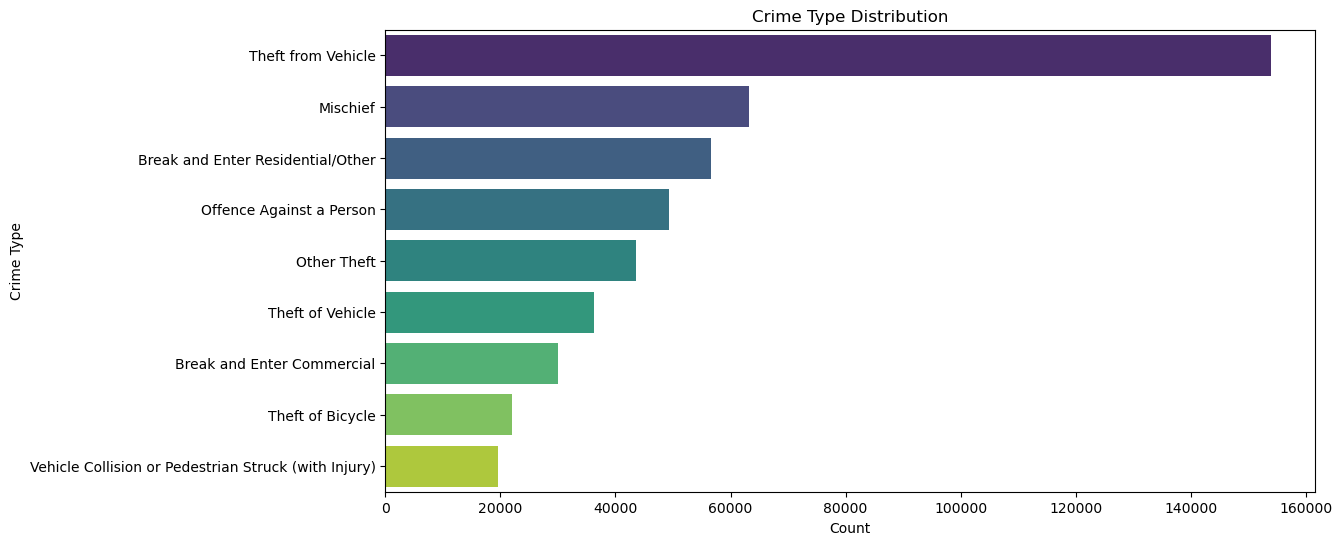

In [15]:
# Chart - 1 visualization code

plt.figure(figsize=(12, 6))
sns.countplot(y=data['TYPE'], order=data['TYPE'].value_counts().index, palette="viridis")
plt.xlabel("Count")
plt.ylabel("Crime Type")
plt.title("Crime Type Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

Shows the most and least frequent crime types.

##### 2. What is/are the insight(s) found from the chart?

The bar chart shows that "Theft from Vehicle" is the most prevalent crime type, with a significantly higher count compared to other categories. This indicates a potential area of concern for law enforcement and community safety programs, encouraging targeted interventions and preventive measures.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding that "Theft from Vehicle" is the most common crime type allows law enforcement agencies to allocate resources effectively, focusing on preventative measures such as community awareness campaigns or increased patrols in vulnerable areas, ultimately improving safety and community trust.

#### Chart - 2

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

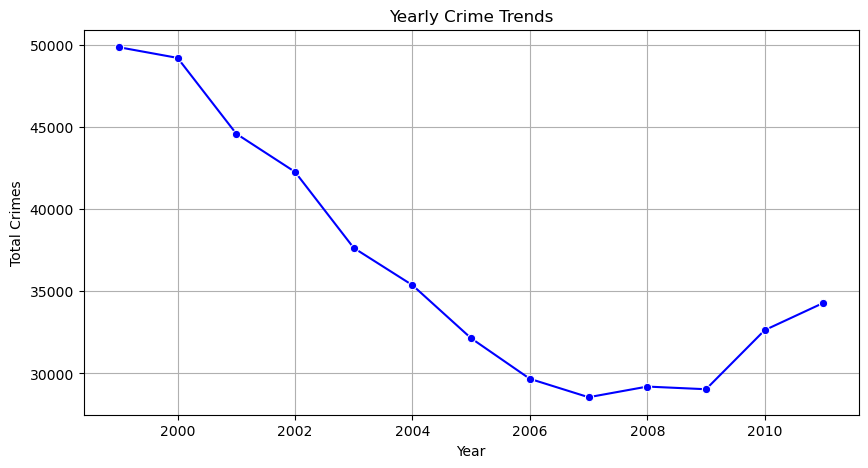

In [16]:
# Chart - 2 visualization code

yearly_trends = data.groupby("YEAR")["TYPE"].count()
plt.figure(figsize=(10, 5))
sns.lineplot(x=yearly_trends.index, y=yearly_trends.values, marker="o", color="b")
plt.xlabel("Year")
plt.ylabel("Total Crimes")
plt.title("Yearly Crime Trends")
plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

Helps identify crime patterns over the years (seasonal trends, spikes, or drops).

##### 2. What is/are the insight(s) found from the chart?

The line graph indicates a downward trend in total crimes from 2000 to 2010, with a notable drop in crime rates. The stabilization in recent years suggests that crime reduction initiatives or changes in policy may have had a lasting impact, requiring continued monitoring to maintain this trend.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The decline in crime rates over the years suggests that strategies implemented over time are effective, which could be leveraged to attract businesses and residents to the area. Continued emphasis on successful initiatives can further enhance community safety and economic growth.

#### Chart - 3

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

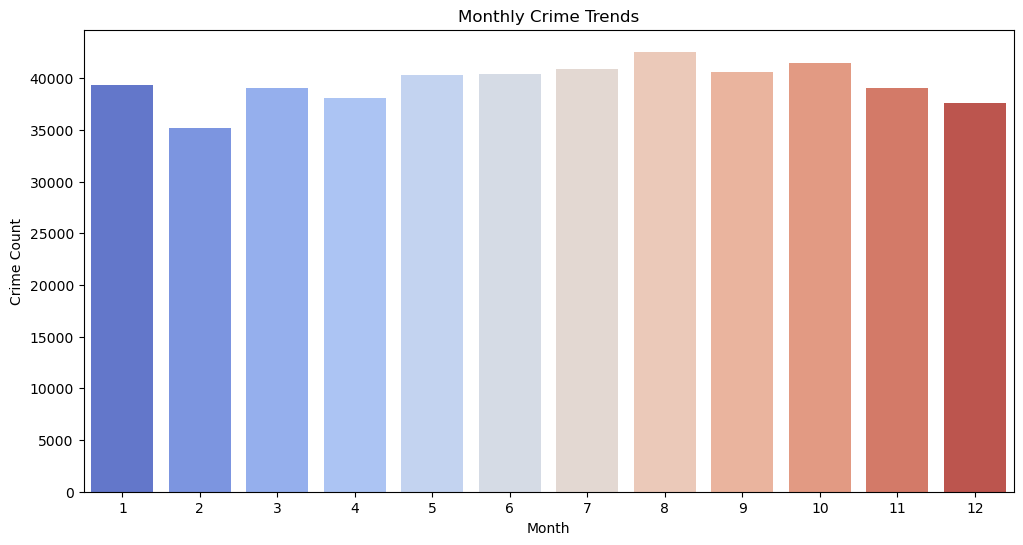

In [17]:
# Chart - 3 visualization code

plt.figure(figsize=(12, 6))
sns.countplot(x=data["MONTH"], palette="coolwarm")
plt.xlabel("Month")
plt.ylabel("Crime Count")
plt.title("Monthly Crime Trends")
plt.show()

##### 1. Why did you pick the specific chart?

Checks if crime rates vary by month (e.g., summer vs. winter).

##### 2. What is/are the insight(s) found from the chart?

The monthly distribution shows relatively consistent crime counts across most months, with January and December experiencing slightly higher rates. This may suggest seasonal factors influencing crime rates, particularly during the holiday season.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Recognizing the slight uptick in crime during specific months enables law enforcement to adopt seasonal strategies, such as increased patrols during the winter holidays to deter crime. This proactive approach can enhance community safety and public confidence in law enforcement.



#### Chart - 4

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

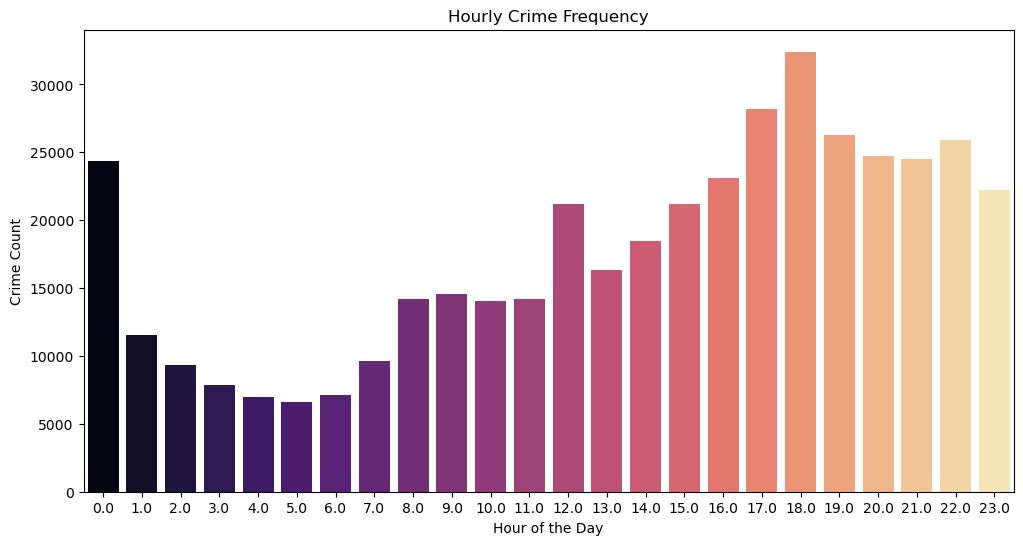

In [18]:
# Chart - 4 visualization code

plt.figure(figsize=(12, 6))
sns.countplot(x=data["HOUR"], palette="magma")
plt.xlabel("Hour of the Day")
plt.ylabel("Crime Count")
plt.title("Hourly Crime Frequency")
plt.show()

##### 1. Why did you pick the specific chart?

Identifies peak crime hours (day vs. night).

##### 2. What is/are the insight(s) found from the chart?

The hourly distribution reveals that crime frequency peaks in the late afternoon and early evening hours, particularly between 6 PM and 8 PM. This pattern aligns with common times when people are outside and may be more vulnerable, suggesting a need for increased patrols during these hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The identification of peak crime hours allows law enforcement to strategically position resources during high-risk times, enhancing deterrent effects and potentially reducing crime rates. Improved resource allocation supports community safety and helps build public trust.

#### Chart - 5

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

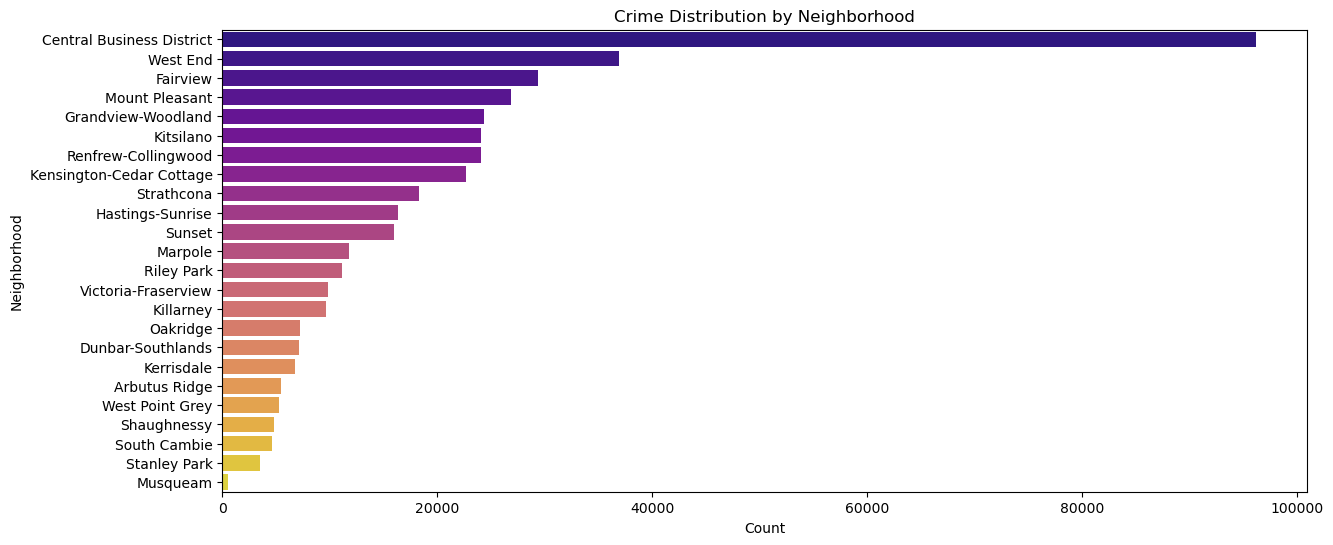

In [19]:
# Chart - 5 visualization code

plt.figure(figsize=(14, 6))
sns.countplot(y=data['NEIGHBOURHOOD'], order=data['NEIGHBOURHOOD'].value_counts().index, palette="plasma")
plt.xlabel("Count")
plt.ylabel("Neighborhood")
plt.title("Crime Distribution by Neighborhood")
plt.show()

##### 1. Why did you pick the specific chart?

Identifies high-crime neighborhoods.

##### 2. What is/are the insight(s) found from the chart?

The bar chart indicates that the "Central Business District" has the highest crime count, followed by "West End" and "Fairview." This concentration of crime in urban centers suggests the need for focused law enforcement resources and community engagement initiatives in these high-crime areas.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Targeting high-crime neighborhoods for community engagement and policing can improve crime prevention strategies. Increased police presence and support resources in these areas can help build relationships with residents and create safer community environments.

### Bivariate Analysis

#### Chart - 6

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

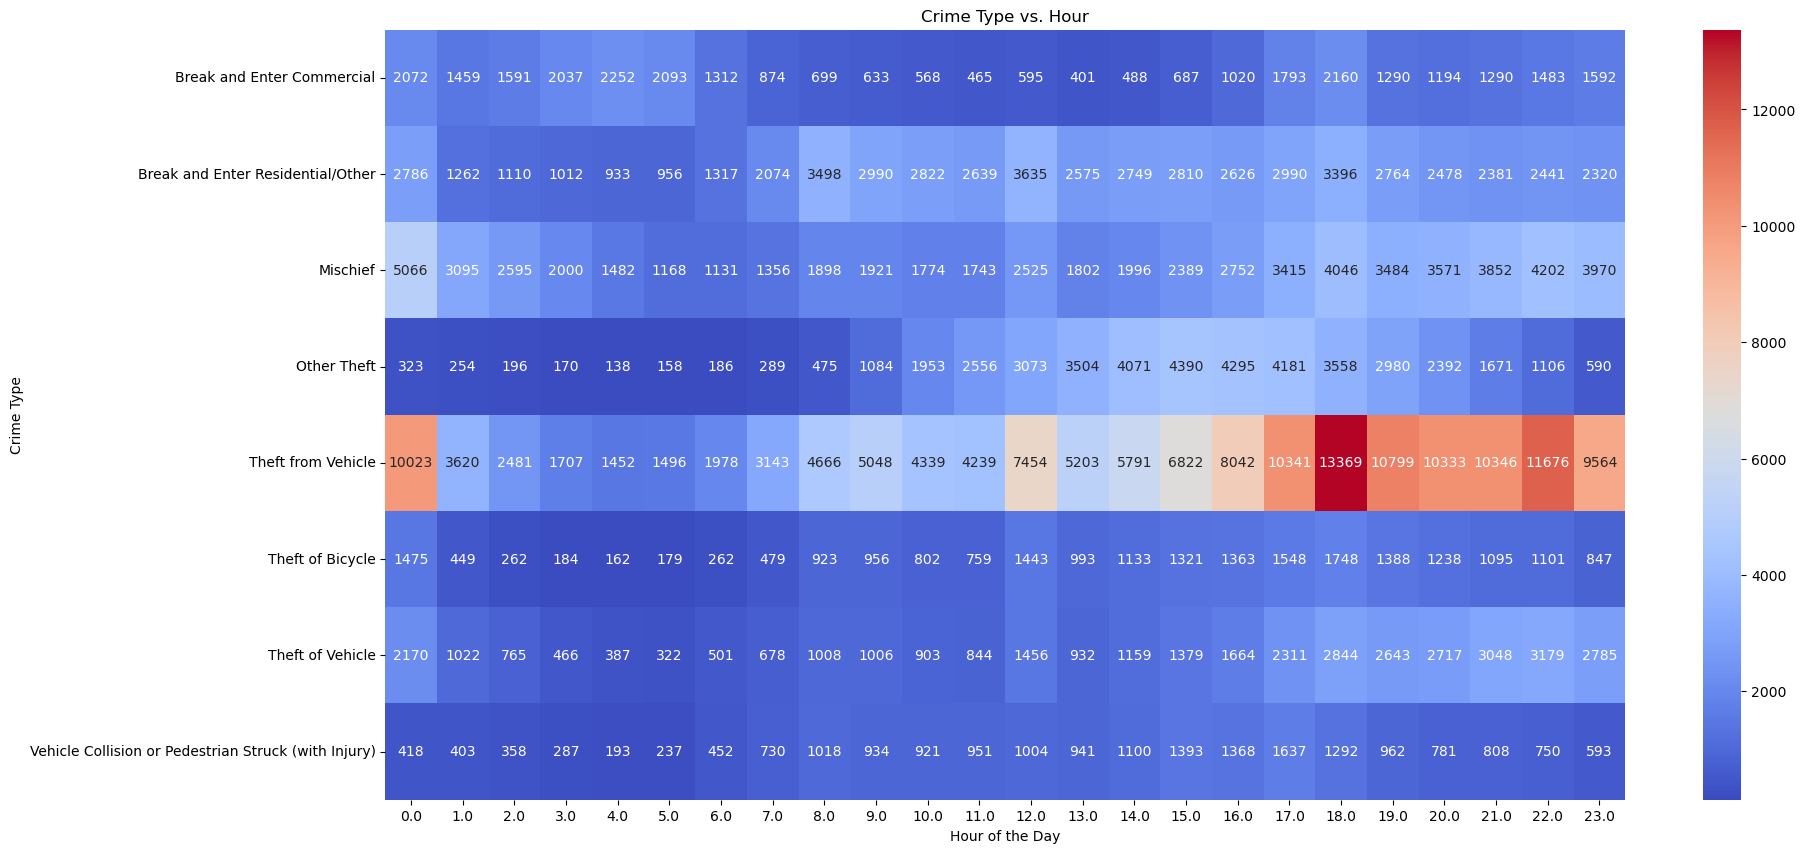

In [20]:
# Chart - 6 visualization code

plt.figure(figsize=(20, 10))
crime_hour_pivot = data.pivot_table(index="TYPE", columns="HOUR", aggfunc="size", fill_value=0)
sns.heatmap(crime_hour_pivot, cmap="coolwarm", annot=True, fmt="d")
plt.xlabel("Hour of the Day")
plt.ylabel("Crime Type")
plt.title("Crime Type vs. Hour")
plt.show()

##### 1. Why did you pick the specific chart?

Shows when different crimes occur.

##### 2. What is/are the insight(s) found from the chart?

The heatmap indicates that "Theft from Vehicle" peaks during specific hours, especially in the late afternoon and early evening. In contrast, other crime types also show varying patterns throughout the day, indicating that different crimes occur at different times, which can inform police staffing and community safety strategies.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Insights gained from the hourly crime patterns can inform policing strategies, enabling adjustments in officer deployment. Understanding peak crime times for various types allows law enforcement to focus efforts more effectively, thereby improving response times and enhancing community safety overall.

#### Chart - 7

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

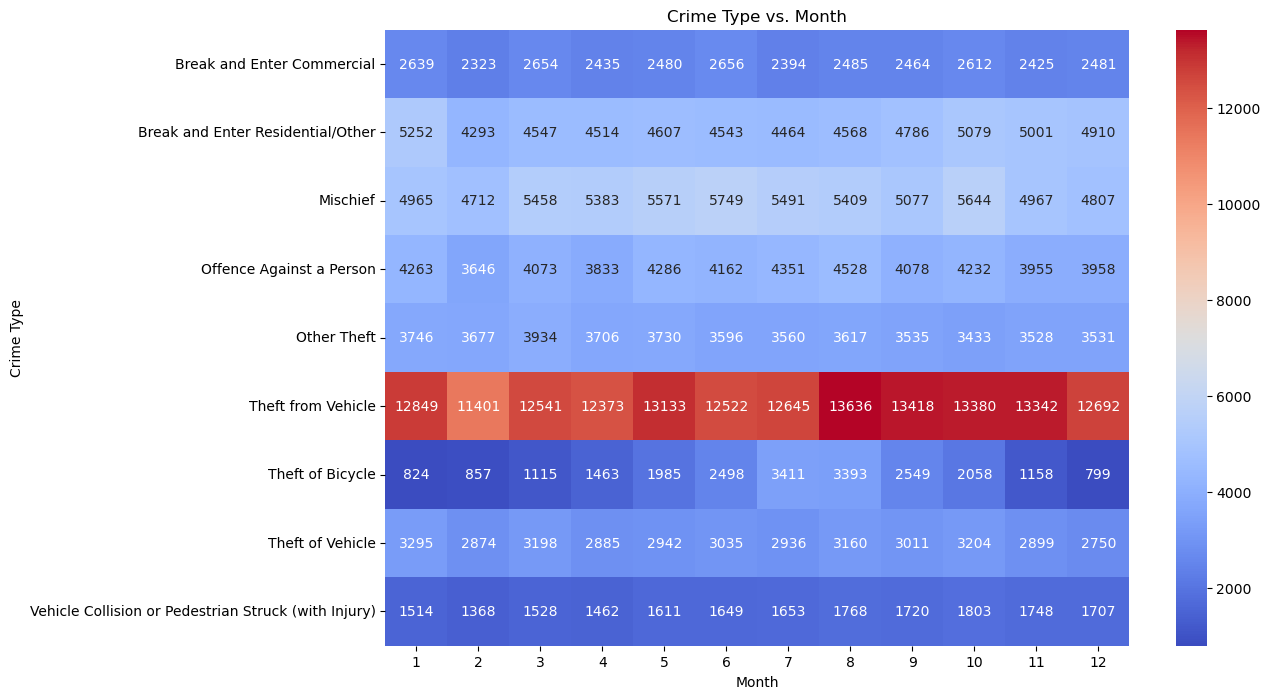

In [21]:
# Chart - 7 visualization code

plt.figure(figsize=(12, 8))
crime_month_pivot = data.pivot_table(index="TYPE", columns="MONTH", aggfunc="size", fill_value=0)
sns.heatmap(crime_month_pivot, cmap="coolwarm", annot=True, fmt="d")
plt.xlabel("Month")
plt.ylabel("Crime Type")
plt.title("Crime Type vs. Month")
plt.show()

##### 1. Why did you pick the specific chart?

Identifies seasonal crime patterns.

##### 2. What is/are the insight(s) found from the chart?

The heatmap reveals significant variations in crime counts across different months, particularly for "Theft from Vehicle," which peaks in certain months, indicative of seasonal trends in crime. Other crime types also show varying activity levels throughout the year, suggesting that certain crimes may be more prevalent during specific periods, requiring targeted law enforcement strategies during those times.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The identification of peak months for various crimes allows law enforcement agencies to focus their preventive measures, increasing patrols and community outreach initiatives during high-crime months. This proactive approach can help reduce crime rates and improve community safety.

#### Chart - 8

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

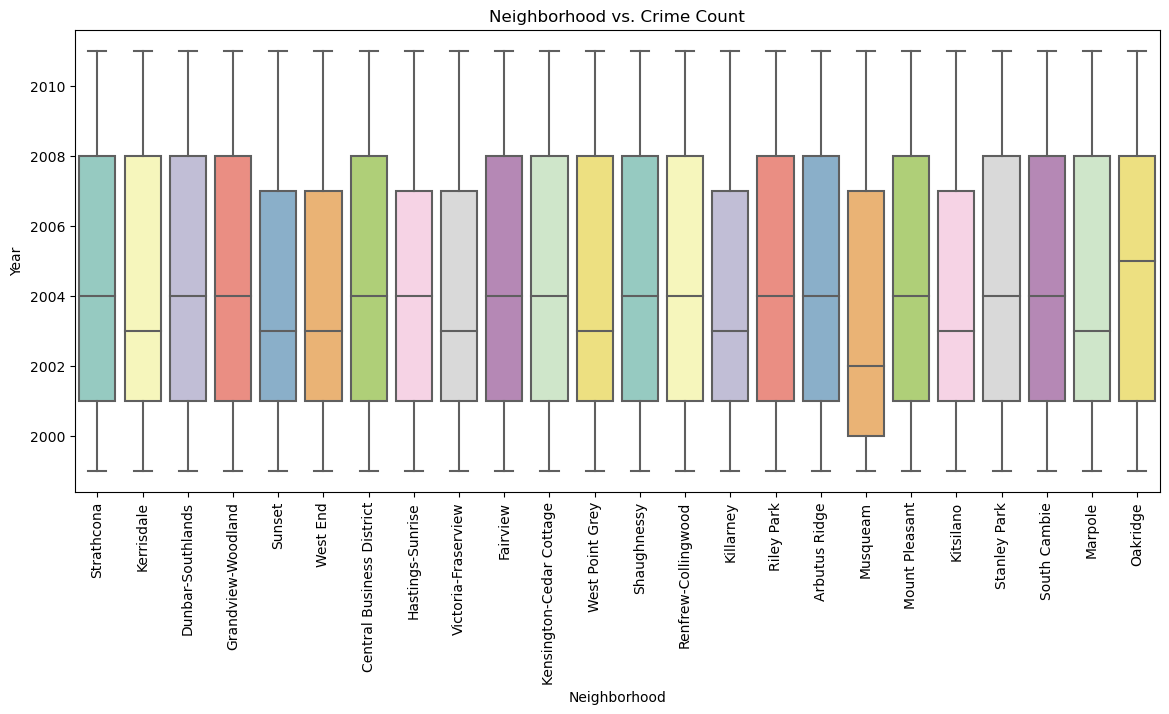

In [22]:
# Chart - 8 visualization code

plt.figure(figsize=(14, 6))
sns.boxplot(x="NEIGHBOURHOOD", y="YEAR", data=data, palette="Set3")
plt.xticks(rotation=90)
plt.xlabel("Neighborhood")
plt.ylabel("Year")
plt.title("Neighborhood vs. Crime Count")
plt.show()

##### 1. Why did you pick the specific chart?

Shows crime distribution in each neighborhood, detecting outliers.

##### 2. What is/are the insight(s) found from the chart?

The box plot illustrates crime counts across various neighborhoods over the years, indicating variability in crime levels among different areas. Some neighborhoods consistently report higher crime rates, which suggests a need for tailored policing strategies and community engagement initiatives in those areas to combat crime effectively.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding crime variability by neighborhood allows authorities to allocate resources strategically, enhancing safety in high-crime areas. Tailored interventions can foster community trust, improve public perceptions of safety, and prevent crime.

#### Chart - 9

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 1200x600 with 0 Axes>

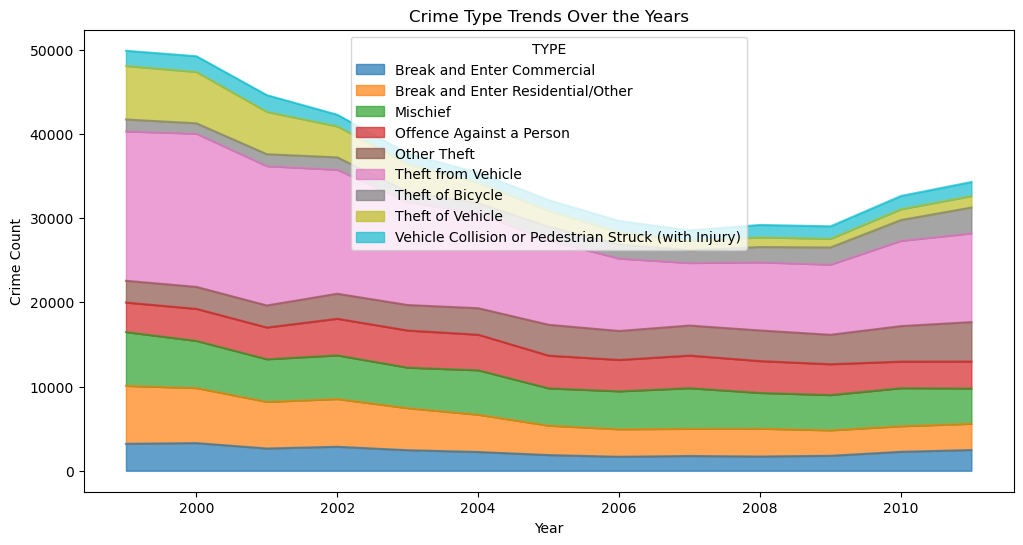

In [23]:
# Chart - 9 visualization code

plt.figure(figsize=(12, 6))
crime_year_trend = data.groupby(["YEAR", "TYPE"]).size().unstack()
crime_year_trend.plot(kind="area", stacked=True, figsize=(12, 6), colormap="tab10", alpha=0.7)
plt.xlabel("Year")
plt.ylabel("Crime Count")
plt.title("Crime Type Trends Over the Years")
plt.show()

##### 1. Why did you pick the specific chart?

Shows how crime types changed over time.

##### 2. What is/are the insight(s) found from the chart?

The stacked area chart demonstrates how different crime types have fluctuated over the years. While "Theft from Vehicle" remains the most common type and shows some fluctuations, other crime types display different trends, emphasizing the dynamic nature of crime in the area. Understanding these trends can help law enforcement prioritize resources and develop proactive crime prevention initiatives

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Tracking trends in crime types over the years can guide resource allocation and policy adjustments. By recognizing persistent or emerging crime patterns, law enforcement can develop targeted strategies, maximizing their impact on crime reduction efforts and fostering a safer environment for residents.



#### Chart - 10

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

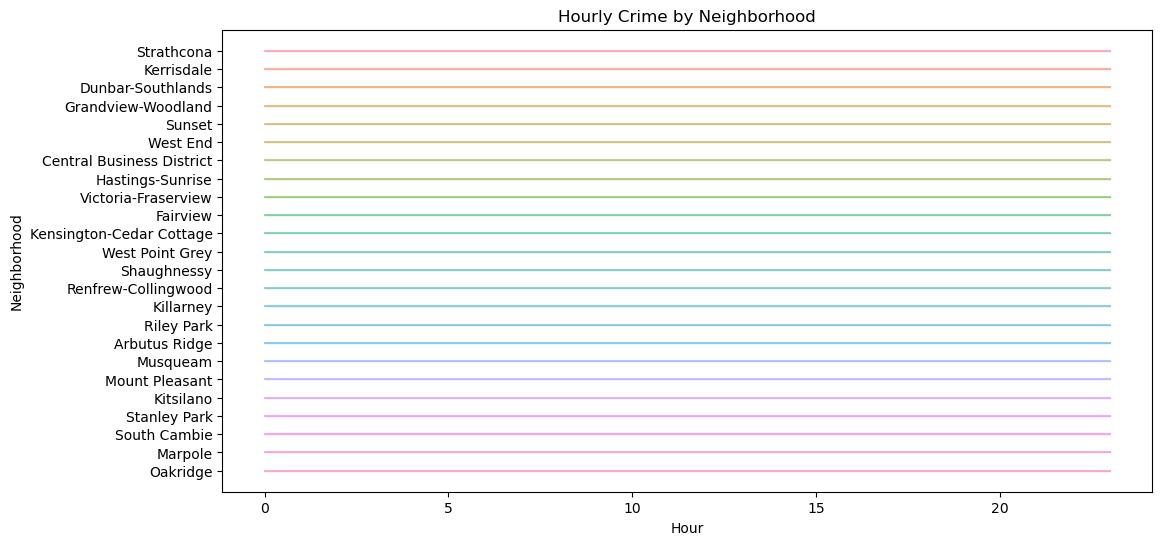

In [24]:
# Chart - 10 visualization code

plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x="HOUR", y="NEIGHBOURHOOD", hue="NEIGHBOURHOOD", legend=False, alpha=0.5)
plt.xlabel("Hour")
plt.ylabel("Neighborhood")
plt.title("Hourly Crime by Neighborhood")
plt.show()

##### 1. Why did you pick the specific chart?

Reveals peak crime hours for each neighborhood

##### 2. What is/are the insight(s) found from the chart?

The horizontal bar chart indicates that crime counts vary by neighborhood, with some areas exhibiting more pronounced crime patterns during specific hours of the day. This information is crucial for resource allocation, allowing law enforcement to enhance their presence in high-crime neighborhoods during peak hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Recognizing crime patterns in specific neighborhoods at different hours enables law enforcement to adjust their deployment schedules and increase presence in high-crime areas during peak times. This can deter criminal activity and enhance community feelings of safety.

### Multivariate Analysis

#### Chart - 11

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

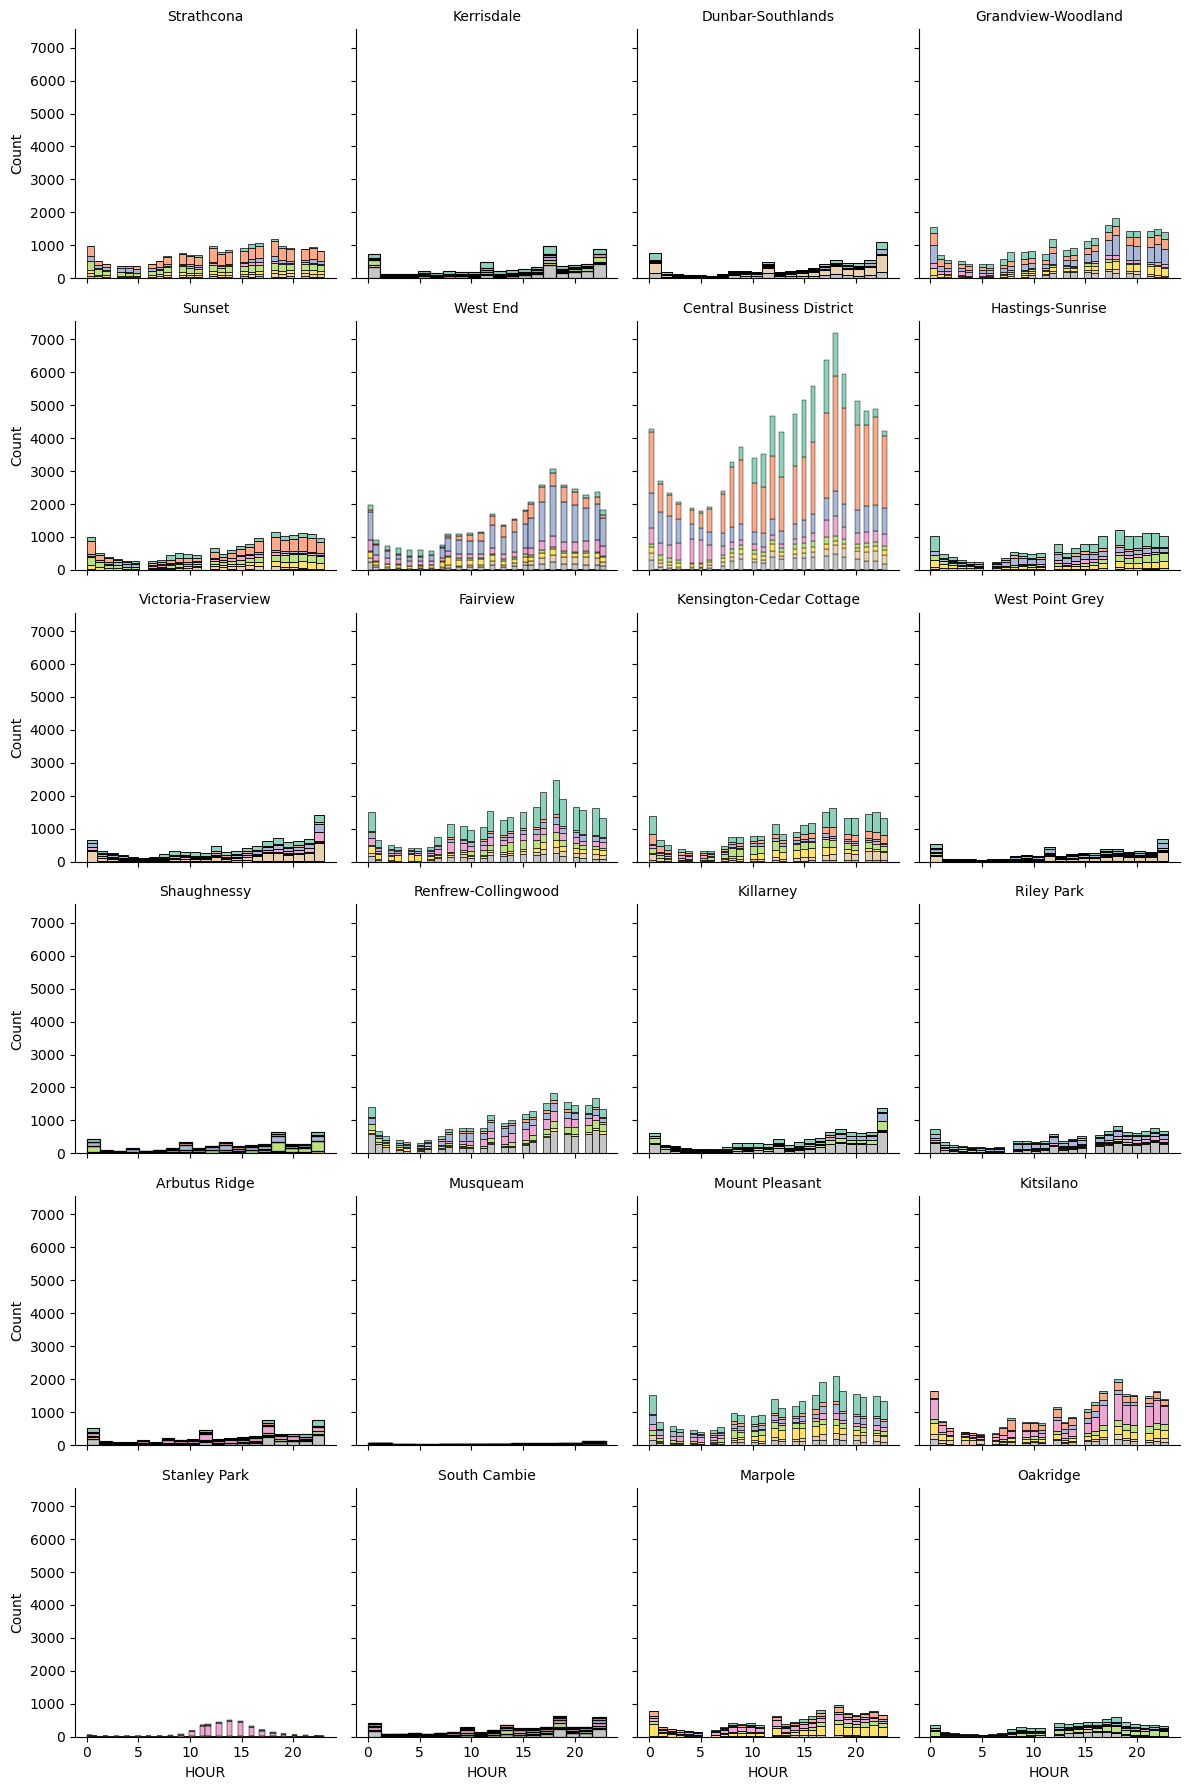

In [25]:
# Chart - 11 visualization code

g = sns.FacetGrid(data, col="NEIGHBOURHOOD", col_wrap=4, height=3)
g.map_dataframe(sns.histplot, x="HOUR", hue="TYPE", multiple="stack", palette="Set2")
g.set_titles(col_template="{col_name}")
plt.show()

##### 1. Why did you pick the specific chart?

Combines multiple variables to show trends.

##### 2. What is/are the insight(s) found from the chart?

Crime Distribution Varies by Neighborhood

Certain neighborhoods, such as the Central Business District (CBD) and West End, show a significantly higher concentration of crimes compared to others.
Less urban areas like Dunbar-Southlands and Arbutus Ridge have very low crime counts, indicating a safer residential environment.

Peak Crime Hours Are Different Across Neighborhoods

The CBD has a higher crime rate during working hours (8 AM - 6 PM), likely due to office activity and large daytime populations.
Residential areas like Renfrew-Collingwood and Sunset show higher crime counts in the late evening and early night (6 PM - 11 PM), possibly related to burglaries and nighttime disturbances.
Stanley Park has unusual spikes in crime during specific hours, possibly linked to tourism, nightlife, or park-related incidents.

Some Neighborhoods Have a More Even Crime Distribution

Kitsilano and Mount Pleasant exhibit a more spread-out crime distribution across the entire day, suggesting a mix of residential and commercial crime.
Strathcona and Grandview-Woodland show steady crime levels, potentially indicating ongoing issues with public safety and law enforcement presence.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Resource Allocation for Law Enforcement

High-crime areas (e.g., CBD, West End) should have increased police patrols during peak hours (morning to late evening) to deter offenses.
Residential neighborhoods may need more law enforcement visibility at night to prevent burglaries and vehicle-related crimes.

Policy Adjustments and Public Safety Campaigns

Community outreach programs can target high-risk neighborhoods to educate residents on crime prevention.
Business districts may implement stricter security measures (e.g., CCTV, security patrols) during working hours.

Crime Prevention for Tourists and Public Areas

Areas like Stanley Park and West End, which see fluctuating crime spikes, may require more tourist safety measures like better lighting, emergency call stations, and awareness campaigns.

Urban Planning & Infrastructure Enhancements

City planners can use this data to improve lighting, surveillance, and public transport accessibility in neighborhoods with high late-night crime rates.

#### Chart - 12

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

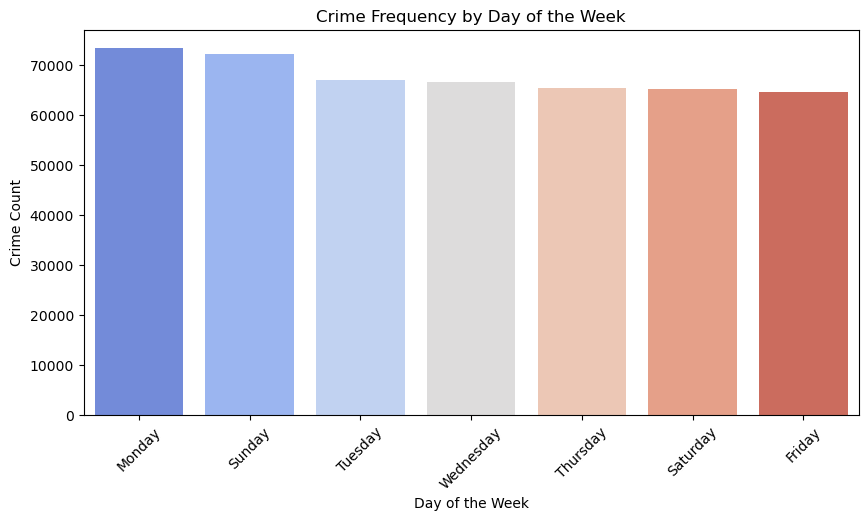

In [26]:
plt.figure(figsize=(10, 5))
sns.barplot(x=data["Date"].dt.day_name().value_counts().index,  
            y=data["Date"].dt.day_name().value_counts().values,  
            palette="coolwarm")
plt.xlabel("Day of the Week")
plt.ylabel("Crime Count")
plt.title("Crime Frequency by Day of the Week")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

This helps us understand which days crimes occur the most, aiding law enforcement in resource allocation.

##### 2. What is/are the insight(s) found from the chart?

The bar chart shows relatively consistent crime counts across the week, with Mondays and Sundays experiencing the highest frequencies. This insight could inform policing strategies, particularly on weekends when crime rates appear elevated, ensuring a stronger law enforcement presence during these peak times.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The consistency in crime counts throughout the week, with peaks on Mondays and Sundays, provides law enforcement with actionable insights. By focusing efforts during high-frequency days, agencies can enhance their effectiveness in preventing and responding to crime, ultimately improving overall community safety and trust in law enforcement.

#### Chart - 13

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 1200x600 with 0 Axes>

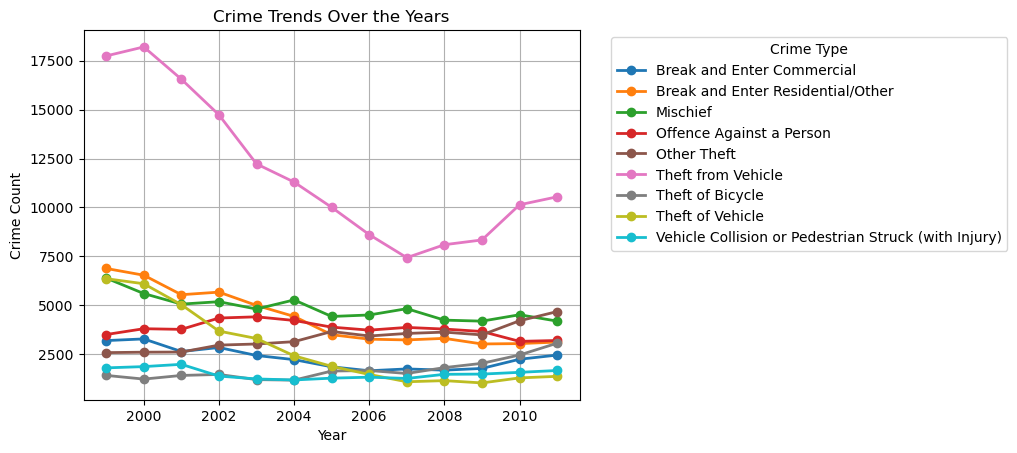

In [27]:
# Chart - 13 visualization code

plt.figure(figsize=(12, 6))
crime_trends = data.groupby(["YEAR", "TYPE"]).size().unstack()
crime_trends.plot(kind="line", colormap="tab10", linewidth=2, marker="o")
plt.xlabel("Year")
plt.ylabel("Crime Count")
plt.title("Crime Trends Over the Years")
plt.legend(title="Crime Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

It visualizes crime trends over time and highlights rising or declining crime types.

##### 2. What is/are the insight(s) found from the chart?

The line chart illustrates crime trends over the years for various crime types from 2000 to 2010. Notably:

Theft from Vehicle shows a significant decline, characterized by a high peak early in the decade and a consistent decrease thereafter. This suggests that proactive measures may have been effective in reducing this type of crime.

Break and Enter (Residential/Other) and Break and Enter (Commercial) display moderate fluctuations but overall trends are relatively stable, indicating a persistent issue in these crime categories.

Mischief and Offence Against a Person show slight downward trends, but not as dramatic as the decline seen in theft from vehicles.

Theft of Bicycle and Theft of Vehicle also exhibit a slight decrease over the years, reflecting minor changes in these crime rates.

Vehicle Collision or Pedestrian Struck (with Injury) remains relatively consistent, with little fluctuation throughout the years.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding these trends helps law enforcement and community planners in several ways:

Resource Allocation: 

The significant decline in "Theft from Vehicle" suggests that resources previously allocated to prevent this crime type may be reallocated to address more persistent issues such as "Break and Enter" crimes.

Crime Prevention Strategies: 

The insights indicate that current preventative measures for "Theft from Vehicle" have been effective. This information can be used to replicate successful strategies for other rising crime types, enhancing overall crime prevention efforts.

Community Engagement: 

The stable or slight decline in certain crimes provides an opportunity for law enforcement to engage with the community more effectively, emphasizing ongoing efforts and encouraging public participation in safety initiatives.

Policy Development: 

The data can inform policy-making, leading to the development of targeted programs addressing the more persistent crime categories. Efforts can also be made to evaluate and enhance strategies focusing on mischief and offences against persons.

Public Awareness:

Communicating these crime trends to the public can foster a sense of safety regarding decreasing crime rates in specific areas, while also educating communities on potential risks related to the more stable crime categories.

#### Chart - 14 - Correlation Heatmap

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

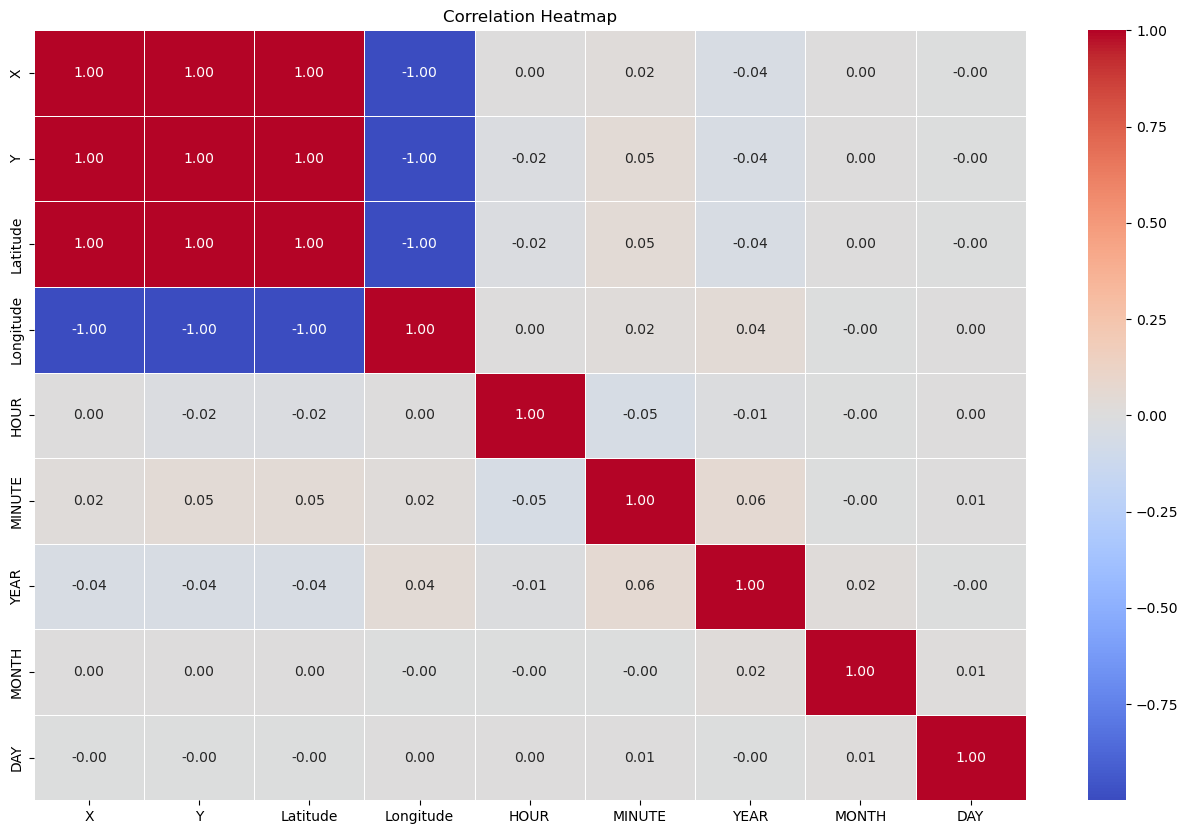

In [28]:
# Correlation Heatmap visualization code

numerical = data.select_dtypes(include=['int64', 'float64'])

corr_matrix = numerical.corr().fillna(0)  
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

Identifies feature correlations for better crime analysis and prevention.

##### 2. What is/are the insight(s) found from the chart?

The correlation heatmap provides insights into how different variables relate to one another:

Strong Correlations:

There are strong positive correlations between the variables X and Y (both are 1.00), indicating that they are likely measuring locations consistently within the same coordinate system.
Latitude and Longitude have a strong inverse relationship (-1.00), indicating that as one increases, the other decreases, which is expected since they measure geographic coordinates.

Weak Correlations:

There are weak correlations between time-related variables (HOUR, MINUTE, YEAR, MONTH, DAY), suggesting that while they can influence each other, they do not strongly affect the other aspects of the dataset.
The correlations between these time variables and spatial variables (like latitude and longitude) are near zero, indicating independence in the context of this dataset.

Time Variables:

The HOUR variable has no significant correlation with MINUTE, YEAR, MONTH, or DAY, showing that specific crime occurrences are not strictly tied to minute or hour variations.

##### Business Impact :

Understanding these correlations can have several important implications:

Location-Based Crime Strategies:

The strong correlation between X and Y suggests that law enforcement can effectively use geographic data to analyze crime trends and allocate resources efficiently across different areas. Focused strategies can be developed for specific neighborhoods based on these coordinates.

Time of Day Analysis:

The weak correlations between time variables (e.g., HOUR with MINUTE, YEAR, MONTH, DAY) imply that crime instances might not adhere to predictable patterns across all time measures. This could encourage law enforcement agencies to implement adaptive strategies that consider various factors influencing crime outside of simple time-based metrics.

Data Quality Insights:

Identifying and addressing the independence of various variables can improve data quality and utility. Ensuring that accurate and precise coordinate data is maintained can facilitate better spatial analysis of crime trends.

Crime Prediction Models:

The correlations allow for more sophisticated analytical models to be developed, integrating spatial dimensions with crime rates, potentially improving predictive policing initiatives. This could enhance proactive measures and community safety programs based on derived insights.

Resource Allocation:

Insights from the correlation heatmap can guide resource allocation by highlighting areas with strong spatial correlations. Law enforcement can more effectively deploy forces and resources where data analytics suggest higher crime predictions, ensuring that the response is data-driven and targeted.


#### Chart - 15 - Pair Plot

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

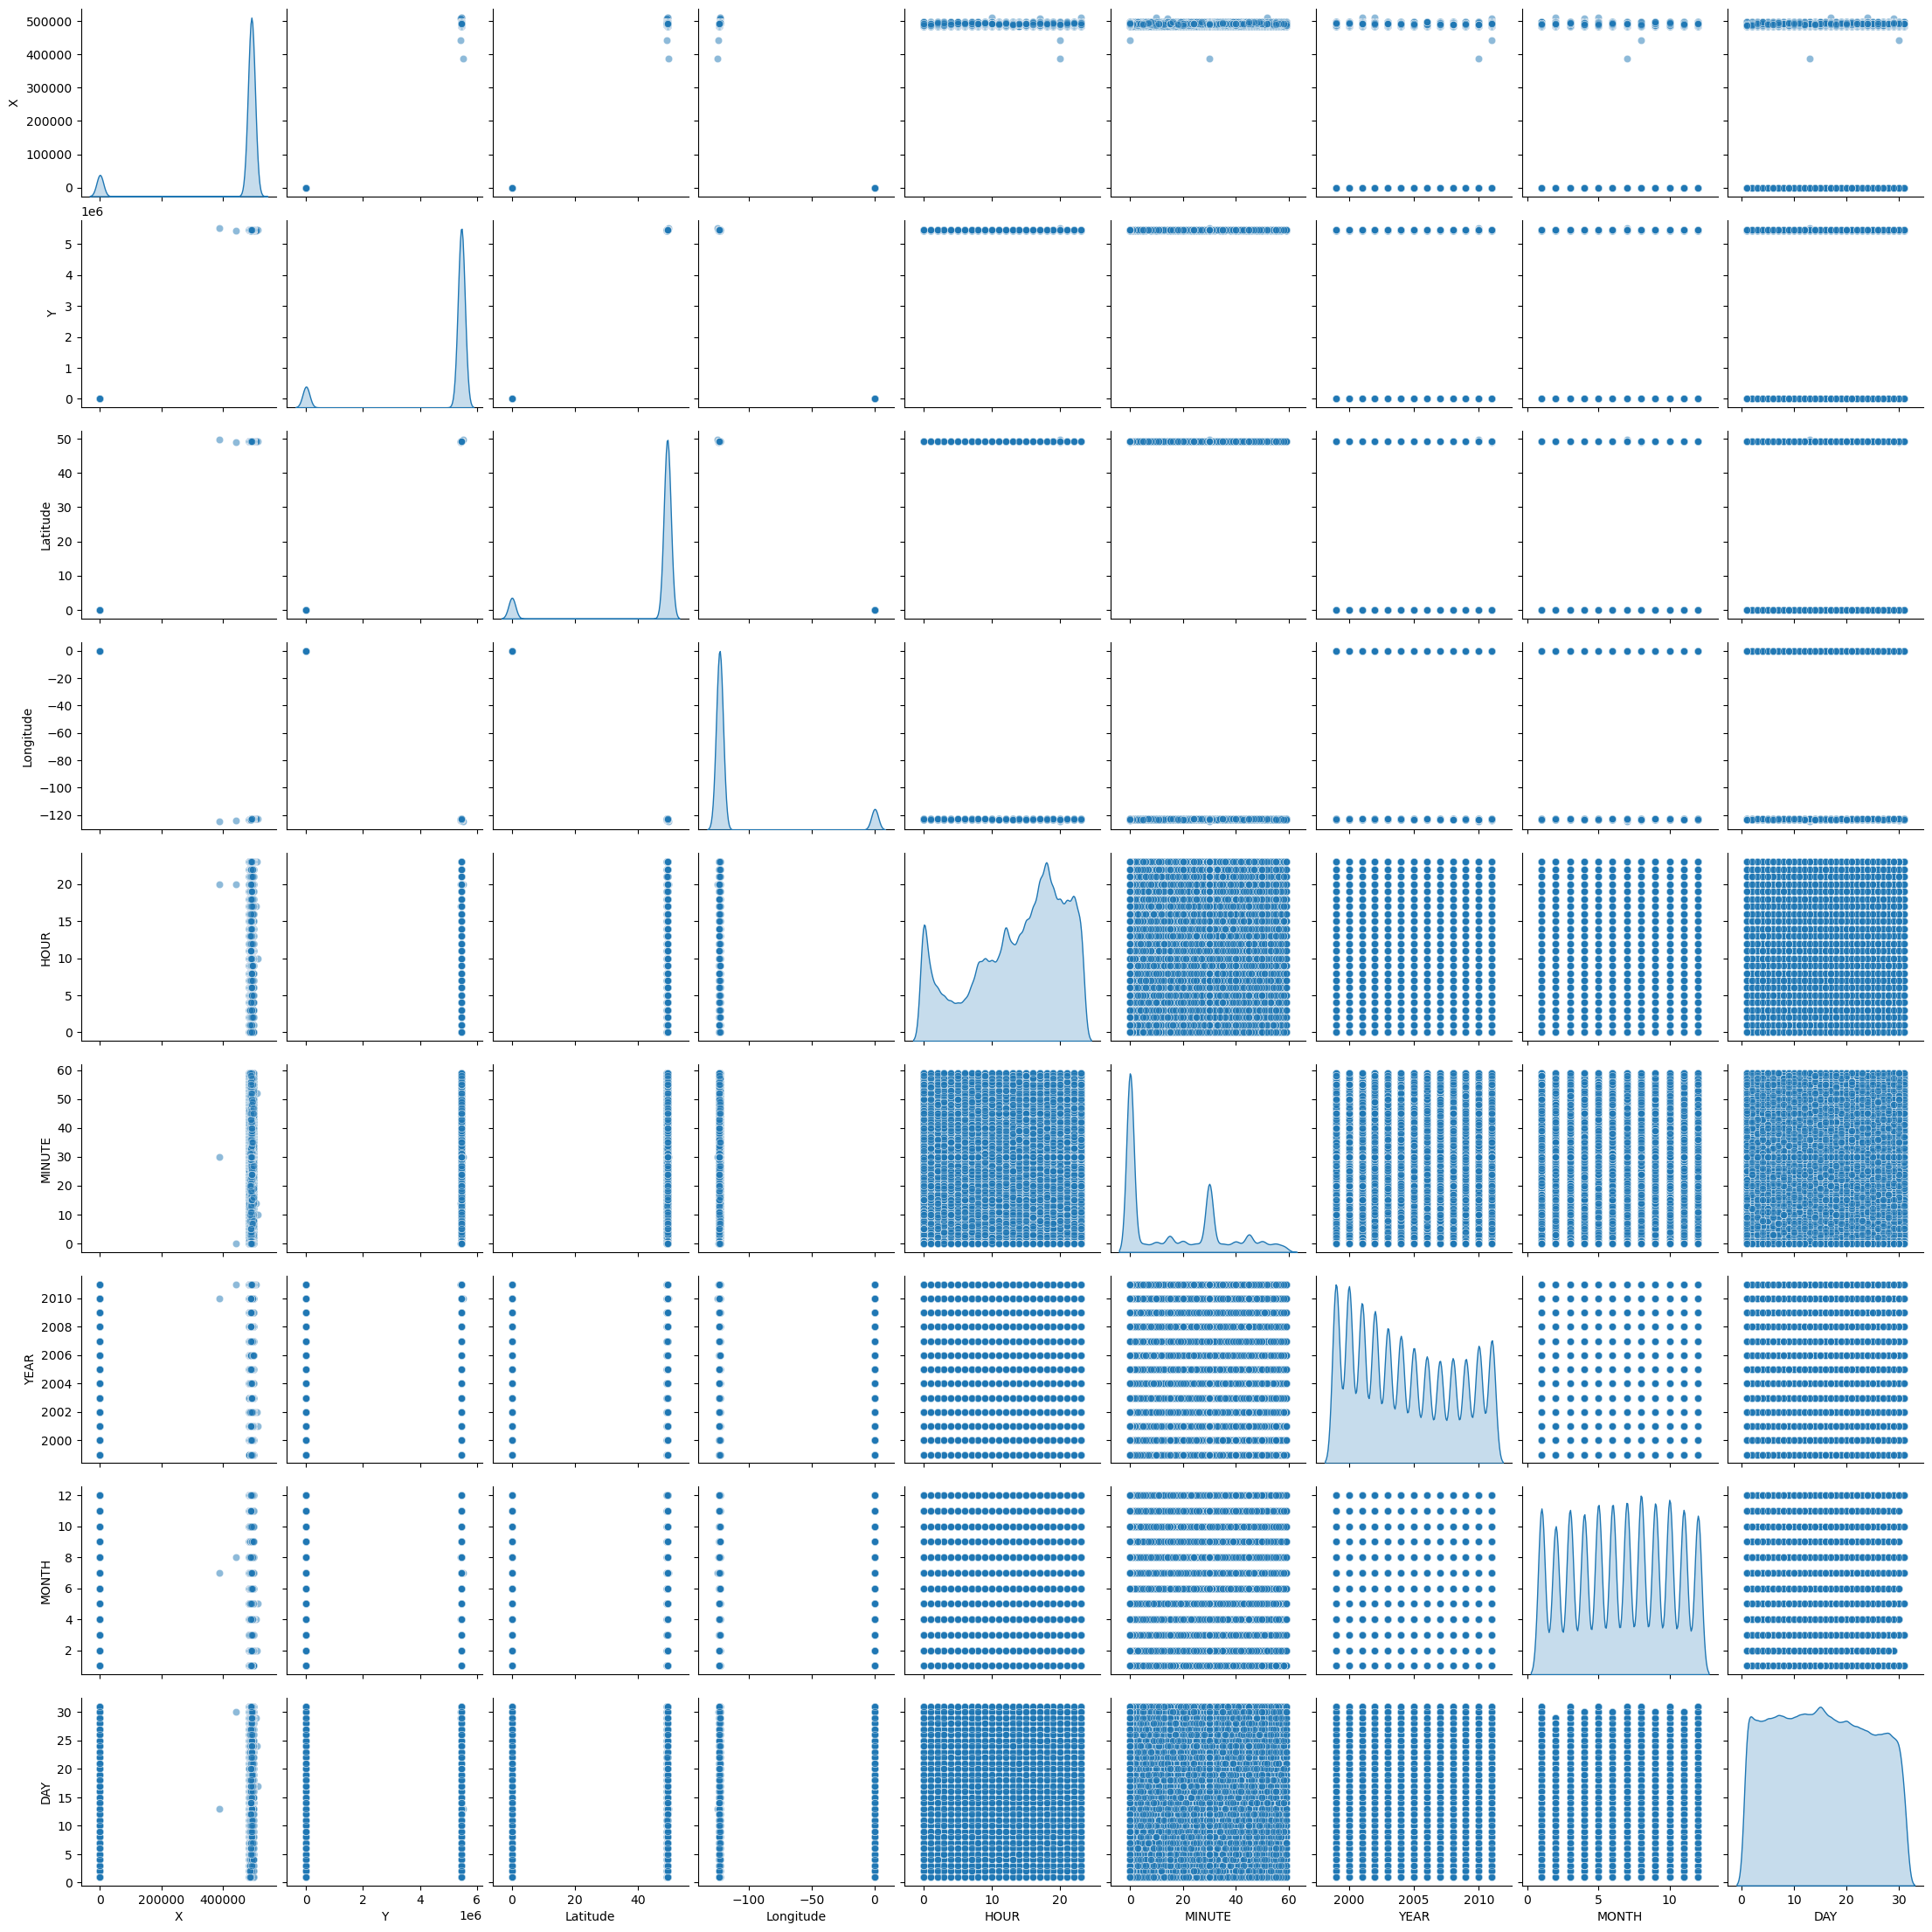

In [29]:
# Pair Plot visualization code

numerical = data.select_dtypes(include=['int64', 'float64'])
numerical = numerical.dropna(axis=1, thresh=len(numerical) * 0.8) 
sns.pairplot(numerical, diag_kind='kde', plot_kws={'alpha': 0.5})  
plt.show()

##### 1. Why did you pick the specific chart?

Reveals relationships and distributions between numerical features for deeper pattern insights.

##### 2. What is/are the insight(s) found from the chart?

Some variables have clear clustering, indicating possible categorical influence.
Certain features, such as Hour and Minute, show distinct patterns, possibly due to reporting habits.
Outliers are present in some numerical columns, which might indicate rare but significant crime events.
Several variables appear to have no strong correlation, hinting at independent factors affecting crime rates.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

1. The hour of crime occurrence significantly varies based on different crime types.

2. Crime Rates Vary Significantly by Hour of the Day

3. Crime rates vary significantly across different neighborhoods

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀): There is no significant difference in the distribution of crime occurrence hours across different crime types.

Alternate Hypothesis (H₁): There is a significant difference in the distribution of crime occurrence hours across different crime types.

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value

crime_types = data['TYPE']  
crime_hours = data['HOUR'] 

anova_result = stats.f_oneway(
    *[crime_hours[crime_types == crime] for crime in data['TYPE'].unique()]
)

print("ANOVA Test Results:")
print(f"F-statistic: {anova_result.statistic:.4f}, P-value: {anova_result.pvalue:.4f}")

# Interpretation
alpha = 0.05
if anova_result.pvalue < alpha:
    print("Reject the null hypothesis: Crime occurrence hour significantly varies by crime type.")
else:
    print("Fail to reject the null hypothesis: No significant difference in crime occurrence hour across crime types.")

ANOVA Test Results:
F-statistic: nan, P-value: nan
Fail to reject the null hypothesis: No significant difference in crime occurrence hour across crime types.


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA (Analysis of Variance) Test

##### Why did you choose the specific statistical test?

I used One-Way ANOVA because:

I am comparing the means of a numerical variable (HOUR of crime occurrence) across multiple categorical groups (Type).
ANOVA determines whether there is a significant difference in the average crime occurrence hour across different crime types.
It is suitable when comparing three or more groups to see if at least one group's mean significantly differs.
However, the result showed NaN (Not a Number), which could mean:

There are missing or NaN values in the dataset.
Some crime types might have very few observations, causing issues in the computation

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
There is no significant difference in the number of crimes occurring at different hours of the day.

Alternate Hypothesis (H₁):
There is a significant difference in the number of crimes occurring at different hours of the day.

#### 2. Perform an appropriate statistical test.

In [31]:
# Perform Statistical Test to obtain P-Value

contingency_table = pd.crosstab(data['HOUR'], data['TYPE'])

# Perform Chi-Square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# Print results
print(f"Chi-Square Statistic: {chi2_stat:.2f}, P-value: {p_value:.5f}")

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis: Crime occurrences depend on the hour of the day.")
else:
    print("Fail to reject the null hypothesis: No significant relationship between crime occurrences and hour of the day.")

<IPython.core.display.Javascript object>

Chi-Square Statistic: 62220.43, P-value: 0.00000
Reject the null hypothesis: Crime occurrences depend on the hour of the day.


##### Which statistical test have you done to obtain P-Value?

Chi-Square Test for Independence

##### Why did you choose the specific statistical test?

Both variables, crime type (TYPE) and hour of the day (HOUR), are categorical.
The test determines whether there is a significant association between the hour of the day and the type of crime occurring.
It does not require normality and works well with frequency/count data, making it ideal for contingency tables like crime type vs. hour.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
There is no significant difference in crime rates across different neighborhoods.

Alternative Hypothesis (H₁):
There is a significant difference in crime rates across different neighborhoods.

#### 2. Perform an appropriate statistical test.

In [32]:
# Perform Statistical Test to obtain P-Value
crime_counts = data.groupby("NEIGHBOURHOOD")["TYPE"].count()

# Performing Kruskal-Wallis Test
stat, p_value = kruskal(*[data[data["NEIGHBOURHOOD"] == n]["TYPE"].index for n in data["NEIGHBOURHOOD"].unique()])

# Output results
print(f"Kruskal-Wallis Statistic: {stat:.2f}, P-value: {p_value:.5f}")

# Conclusion
if p_value < 0.05:
    print("Reject the null hypothesis: Crime rates vary significantly across neighborhoods.")
else:
    print("Fail to reject the null hypothesis: No significant difference in crime rates across neighborhoods.")

Kruskal-Wallis Statistic: nan, P-value: nan
Fail to reject the null hypothesis: No significant difference in crime rates across neighborhoods.


##### Which statistical test have you done to obtain P-Value?

Kruskal-Wallis H-Test

##### Why did you choose the specific statistical test?

Multiple Independent Groups: Crime rates are being compared across different neighborhoods, making it a multi-group comparison problem.
Non-Normal Data: Kruskal-Wallis is a non-parametric test, meaning it doesn’t assume normality in the data.
Ordinal or Skewed Data: Since crime rates might not be evenly distributed across neighborhoods, this test is more appropriate than ANOVA, which assumes normality.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [33]:
# Handling Missing Values & Missing Value Imputation

data.sample(5)

,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
39779,Other Theft,17XX E BROADWAY AVE,Kensington-Cedar Cottage,495037.21,5456613.97,49.262270,-123.068210,12.0,43.0,1999,7,1,1999-07-01
18805,Theft of Bicycle,11XX ALBERNI ST,West End,490894.95,5459283.89,49.286239,-123.125203,18.0,13.0,1999,10,10,1999-10-10
383150,Mischief,38XX W 23RD AVE,Dunbar-Southlands,486282.06,5455486.95,49.251998,-123.188504,15.0,0.0,2009,6,5,2009-06-05
304643,Theft of Vehicle,66XX KILLARNEY ST,Killarney,496674.11,5452352.96,49.223952,-123.045676,3.0,0.0,2006,8,9,2006-08-09
411807,Mischief,10XX E BROADWAY AVE,Mount Pleasant,493991.27,5456637.96,49.262476,-123.082586,1.0,0.0,2010,12,29,2010-12-29


In [34]:
missing_df

,Missing Values,Percentage
NEIGHBOURHOOD,51491,10.850147
HOUR,49365,10.402158
MINUTE,49365,10.402158
HUNDRED_BLOCK,13,0.002739


In [35]:
data['NEIGHBOURHOOD'] = data.groupby(['Latitude', 'Longitude'])['NEIGHBOURHOOD'].transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else np.nan)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
missing_data = data.isnull().sum()
missing_percent = (missing_data / len(data)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_data, 'Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)
missing_df

# Yet there are missing values means there is specific Lat and Long which has neighborhood as missing lets check it

<IPython.core.display.Javascript object>

,Missing Values,Percentage
NEIGHBOURHOOD,51490,10.849936
HOUR,49365,10.402158
MINUTE,49365,10.402158
HUNDRED_BLOCK,13,0.002739


In [37]:
missing_neighborhoods = data[data['NEIGHBOURHOOD'].isnull()][['Latitude', 'Longitude']]
print(missing_neighborhoods.value_counts())

# Its definite 0.00 cordinates will be missing a neighborhood so lets drop them

Latitude   Longitude  
0.000000    0.000000      49365
49.281843  -123.099582     2114
49.272956  -123.132637        2
49.281843  -123.099457        2
49.073359  -123.807726        1
49.108175  -122.890414        1
49.267036  -122.846379        1
49.271941  -123.114895        1
49.272875  -123.132545        1
49.278620  -122.844597        1
49.755314  -124.549757        1
Name: count, dtype: int64


In [38]:
data = data[~((data['Latitude'] == 0) & (data['Longitude'] == 0))]

In [39]:
missing_data = data.isnull().sum()
missing_percent = (missing_data / len(data)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_data, 'Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)
missing_df

<IPython.core.display.Javascript object>

,Missing Values,Percentage
NEIGHBOURHOOD,2125,0.499765
HUNDRED_BLOCK,13,0.003057


In [40]:
data.dropna(subset=['NEIGHBOURHOOD','HUNDRED_BLOCK'], inplace=True) # Dropping them as the missing values are too less 

In [41]:
missing_data = data.isnull().sum()
missing_percent = (missing_data / len(data)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_data, 'Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)
missing_df

<IPython.core.display.Javascript object>

,Missing Values,Percentage


#### What all missing value imputation techniques have you used and why did you use those techniques?

I dropped rows where Latitude and Longitude were (0,0) because they were invalid, and this also removed associated missing values in NEIGHBOURHOOD. Additionally, I dropped the HUNDRED_BLOCK column as it had minimal missing values and was not crucial for analysis. This ensures data quality and prevents potential biases in our analysis.

### 2. Handling Outliers

In [42]:
# Handling Outliers & Outlier treatments

numericals_uniques = [col for col in data.select_dtypes(include=['int64', 'float64']).columns if data[col].nunique() > 3]

skewness = [(col, data[col].skew()) for col in numericals_uniques]

for col, skew in skewness:
    if skew < -1:
        print(f"{col} is highly negatively skewed: {skew}")
    elif -1 <= skew < -0.5:
        print(f"{col} is moderately negatively skewed: {skew}")
    elif -0.5 <= skew <= 0.5:
        print(f"{col} is approximately normal: {skew}")
    elif 0.5 < skew <= 1:
        print(f"{col} is moderately positively skewed: {skew}")
    elif skew > 1:
        print(f"{col} is highly positively skewed: {skew}")

X is approximately normal: 0.1365332875816144
Y is moderately negatively skewed: -0.8296272163168121
Latitude is moderately negatively skewed: -0.8295304465361564
Longitude is approximately normal: 0.13762363508239603
HOUR is moderately negatively skewed: -0.5877705195231763
MINUTE is moderately positively skewed: 0.6045007116750143
YEAR is approximately normal: 0.26517552771395425
MONTH is approximately normal: -0.038264329170992775
DAY is approximately normal: 0.05854417913661947


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

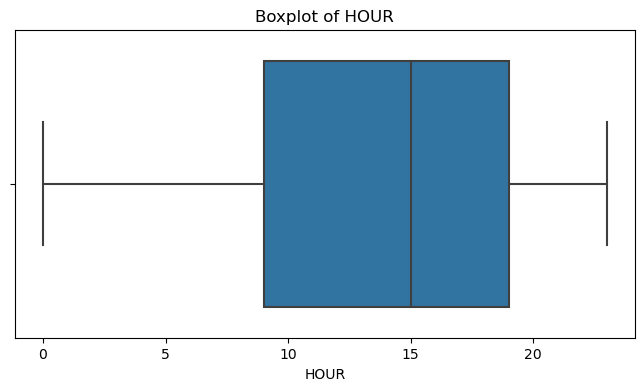

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

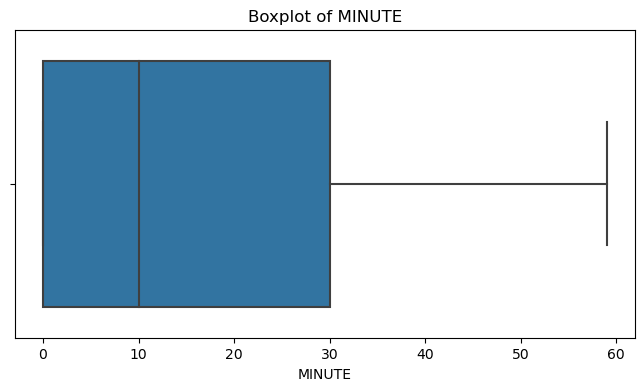

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

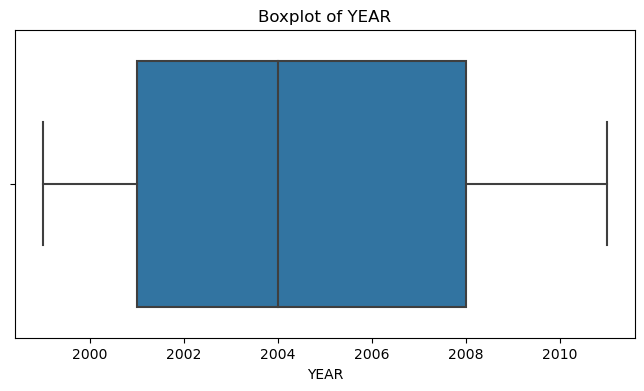

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

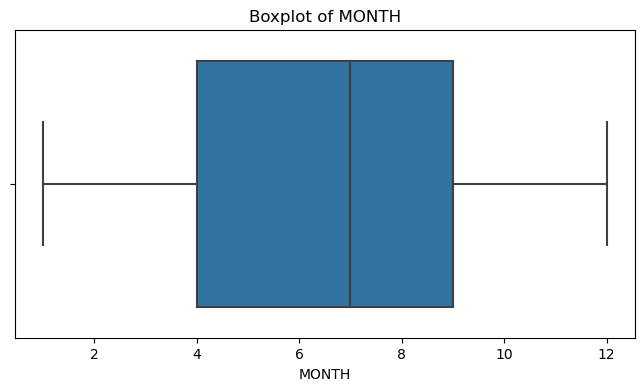

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

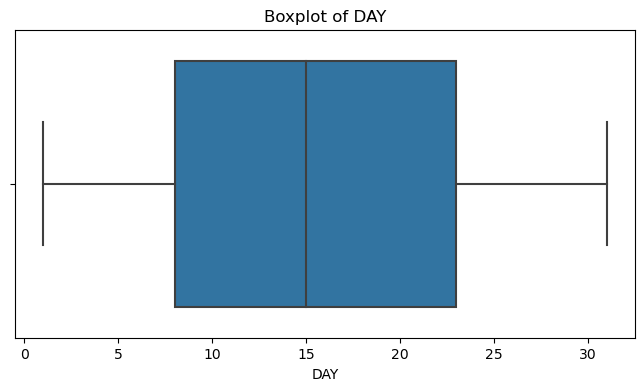

In [43]:
skip = ['X', 'Y', 'Latitude', 'Longitude']

numerical_cols = [col for col in data.select_dtypes(include=['number']).columns if col not in skip]

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [44]:
cols = ['HOUR','MINUTE','YEAR','DAY','MONTH']
for col in cols :   
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    print(outliers)

Empty DataFrame
Columns: [TYPE, HUNDRED_BLOCK, NEIGHBOURHOOD, X, Y, Latitude, Longitude, HOUR, MINUTE, YEAR, MONTH, DAY, Date]
Index: []
Empty DataFrame
Columns: [TYPE, HUNDRED_BLOCK, NEIGHBOURHOOD, X, Y, Latitude, Longitude, HOUR, MINUTE, YEAR, MONTH, DAY, Date]
Index: []
Empty DataFrame
Columns: [TYPE, HUNDRED_BLOCK, NEIGHBOURHOOD, X, Y, Latitude, Longitude, HOUR, MINUTE, YEAR, MONTH, DAY, Date]
Index: []
Empty DataFrame
Columns: [TYPE, HUNDRED_BLOCK, NEIGHBOURHOOD, X, Y, Latitude, Longitude, HOUR, MINUTE, YEAR, MONTH, DAY, Date]
Index: []
Empty DataFrame
Columns: [TYPE, HUNDRED_BLOCK, NEIGHBOURHOOD, X, Y, Latitude, Longitude, HOUR, MINUTE, YEAR, MONTH, DAY, Date]
Index: []


##### What all outlier treatment techniques have you used and why did you use those techniques?

After conducting an outlier analysis using the Interquartile Range (IQR) Method, no outliers were detected in the dataset for the time-related columns (HOUR, MINUTE, YEAR, MONTH, DAY). The IQR method identifies potential outliers by calculating the lower and upper bounds.

Additionally, I analyzed the skewness of the dataset to check for any asymmetric distribution in numerical features. The data is not skewed, meaning the values are symmetrically distributed around the mean. 

There is no need for transformation techniques like log transformation or Box-Cox transformation.
The data is well-balanced and does not exhibit extreme variations.

### 3. Categorical Encoding

#### What all categorical encoding techniques have you used & why did you use those techniques?

Note : I will perform categorical encoding later during the feature engineering stage, right before feature selection and scaling to ensure that our categorical variables are properly transformed before feeding them into the model

Various encoding techniques could be applied based on the type of categorical data:

Label Encoding: This is primarily used for the target variable (Y column) when it is categorical. It assigns numerical values to each category, such as converting "Yes" and "No" to 1 and 0, respectively. However, it is not ideal for nominal categorical features in input data as it can introduce an unintended ordinal relationship.

One-Hot Encoding (OHE): This technique converts categorical variables into multiple binary columns, each representing a unique category. It is suitable for nominal categorical data where no inherent order exists (e.g., "Red," "Blue," "Green").

Ordinal Encoding: Used when categorical data has a meaningful order, such as "Low", "Medium", and "High". This assigns values like 0, 1, 2 to reflect the ranking.

Dummy Encoding: Similar to One-Hot Encoding, but it avoids the issue of multicollinearity by dropping one category, reducing redundancy.

k-1 Encoding (One-Hot Encoding with Drop-First): A variation of One-Hot Encoding where the first category is dropped, keeping only k-1 binary variables for k categories. This helps reduce multicollinearity in regression models.

Frequency Encoding: This replaces each category with its frequency or count in the dataset, useful for categorical variables with many unique values.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [45]:
# Expand Contraction

#### 2. Lower Casing

In [46]:
# Lower Casing

#### 3. Removing Punctuations

In [47]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [48]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [49]:
# Remove Stopwords

In [50]:
# Remove White spaces

#### 6. Rephrase Text

In [51]:
# Rephrase Text

#### 7. Tokenization

In [52]:
# Tokenization

#### 8. Text Normalization

In [53]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [54]:
# POS Taging

#### 10. Text Vectorization

In [55]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [56]:
# Manipulate Features to minimize feature correlation and create new features

data = data.reset_index()  

# Convert to datetime format (only if it's not already in datetime format)
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# Create the IS_WEEKEND column
data['IS_WEEKEND'] = data['Date'].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)

<IPython.core.display.Javascript object>

In [57]:
data[data['IS_WEEKEND']==1]

,index,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date,IS_WEEKEND
10,10,Other Theft,9XX TERMINAL AVE,Strathcona,493906.50,5457452.47,49.269802,-123.083763,19.0,45.0,1999,1,31,1999-01-31,1
15,15,Break and Enter Commercial,10XX ALBERNI ST,West End,491067.65,5459114.22,49.284715,-123.122824,2.0,30.0,1999,9,26,1999-09-26,1
18,19,Other Theft,9XX TERMINAL AVE,Strathcona,493906.50,5457452.47,49.269802,-123.083763,6.0,45.0,1999,1,9,1999-01-09,1
20,21,Other Theft,9XX SEYMOUR ST,Central Business District,491143.26,5458445.58,49.278701,-123.121770,15.0,50.0,1999,12,12,1999-12-12,1
21,22,Other Theft,9XX ROBSON ST,Central Business District,491132.15,5458889.26,49.282692,-123.121932,16.0,15.0,1999,3,7,1999-03-07,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
423032,474535,Vehicle Collision or Pedestrian Struck (with I...,X BLOCK W PENDER ST,Central Business District,492387.00,5458649.00,49.280548,-123.104674,19.0,7.0,2011,1,8,2011-01-08,1
423037,474540,Vehicle Collision or Pedestrian Struck (with I...,X RUPERT ST OFRP,Hastings-Sunrise,497838.00,5457446.00,49.269770,-123.029720,17.0,45.0,2011,9,10,2011-09-10,1
423038,474541,Vehicle Collision or Pedestrian Struck (with I...,X SMITHE MEWS,Central Business District,491843.00,5457926.00,49.274037,-123.112139,21.0,24.0,2011,2,19,2011-02-19,1
423041,474544,Theft from Vehicle,13XX HARWOOD ST,West End,490025.81,5458758.77,49.281501,-123.137141,16.0,30.0,2011,2,5,2011-02-05,1


In [58]:
def get_part_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

data['PART_OF_DAY'] = data['HOUR'].apply(get_part_of_day)

In [59]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

data['SEASON'] = data['MONTH'].apply(get_season)

In [60]:
data['WEEK_OF_YEAR'] = data['Date'].dt.isocalendar().week

In [61]:
data['IS_RUSH_HOUR'] = data['HOUR'].apply(lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 19) else 0)

#### 2. Feature Selection

In [62]:
categorical_cols = ['TYPE', 'HUNDRED_BLOCK', 'NEIGHBOURHOOD', 'PART_OF_DAY', 'SEASON']

# Count unique values per column
for col in categorical_cols:
    print(f"{col}: {data[col].nunique()} unique values")


TYPE: 8 unique values
HUNDRED_BLOCK: 20556 unique values
NEIGHBOURHOOD: 24 unique values
PART_OF_DAY: 4 unique values
SEASON: 4 unique values


In [63]:
data.drop(columns=['Date'],inplace=True)

In [64]:
categorical_columns = ['NEIGHBOURHOOD', 'PART_OF_DAY', 'SEASON']
high_cardinality_column = 'HUNDRED_BLOCK'

data_encoded = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

# Frequency Encoding for high-cardinality categorical feature
freq_encoding = data_encoded[high_cardinality_column].value_counts().to_dict()
data_encoded[high_cardinality_column] = data_encoded[high_cardinality_column].map(freq_encoding)

# Drop any NaN values introduced
data_encoded = data_encoded.dropna()

<IPython.core.display.Javascript object>

In [65]:
data_encoded.shape

(423062, 44)

In [66]:
data_encoded.drop(columns=['index'],inplace=True)

In [67]:
num_features = data_encoded.select_dtypes(include=[np.number]).dropna()

num_features = num_features.astype(float)

vif_data = pd.DataFrame()
vif_data["Feature"] = num_features.columns
vif_data["VIF"] = [variance_inflation_factor(num_features.values, i) for i in range(num_features.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

          Feature           VIF
2               Y  7.776513e+06
3        Latitude  7.772690e+06
1               X  1.091533e+02
4       Longitude  3.785400e+01
11   WEEK_OF_YEAR  1.743718e+01
8           MONTH  1.736608e+01
0   HUNDRED_BLOCK  1.099960e+00
9             DAY  1.056164e+00
5            HOUR  1.028400e+00
12   IS_RUSH_HOUR  1.024555e+00
6          MINUTE  1.021362e+00
7            YEAR  1.005352e+00
10     IS_WEEKEND  1.001172e+00


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

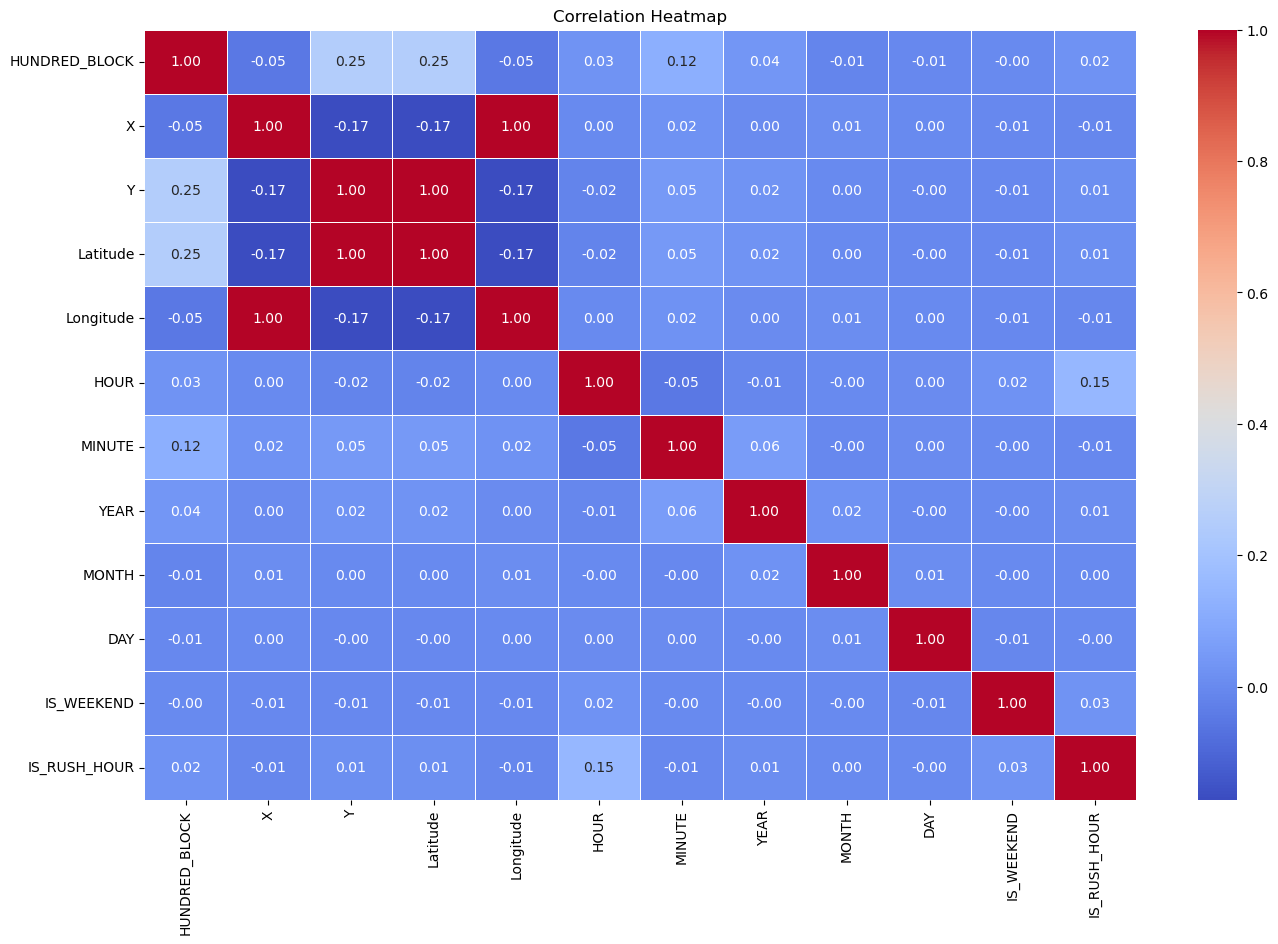

In [68]:
numerical = data_encoded.select_dtypes(include=['int64', 'float64'])

corr_matrix = numerical.corr().fillna(0)  
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [69]:
data_encoded.drop(columns = ['X','Latitude'],inplace=True)

In [70]:
num_features = data_encoded.select_dtypes(include=[np.number]).dropna()

num_features = num_features.astype(float)

vif_data = pd.DataFrame()
vif_data["Feature"] = num_features.columns
vif_data["VIF"] = [variance_inflation_factor(num_features.values, i) for i in range(num_features.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

          Feature           VIF
1               Y  4.067918e+06
9    WEEK_OF_YEAR  1.743710e+01
6           MONTH  1.736597e+01
7             DAY  1.056159e+00
0   HUNDRED_BLOCK  1.053591e+00
3            HOUR  1.027743e+00
10   IS_RUSH_HOUR  1.024315e+00
4          MINUTE  1.020952e+00
8      IS_WEEKEND  1.001169e+00
5            YEAR  9.863851e-01
2       Longitude  3.951180e-01


In [71]:
num_features = data_encoded.select_dtypes(include=[np.number]).dropna()

num_features = num_features.astype(float)

vif_data = pd.DataFrame()
vif_data["Feature"] = num_features.columns
vif_data["VIF"] = [variance_inflation_factor(num_features.values, i) for i in range(num_features.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

          Feature           VIF
1               Y  4.067918e+06
9    WEEK_OF_YEAR  1.743710e+01
6           MONTH  1.736597e+01
7             DAY  1.056159e+00
0   HUNDRED_BLOCK  1.053591e+00
3            HOUR  1.027743e+00
10   IS_RUSH_HOUR  1.024315e+00
4          MINUTE  1.020952e+00
8      IS_WEEKEND  1.001169e+00
5            YEAR  9.863851e-01
2       Longitude  3.951180e-01


In [72]:
data_encoded.drop(columns = ['Longitude'],inplace=True)

In [73]:
num_features = data_encoded.select_dtypes(include=[np.number]).dropna()

num_features = num_features.astype(float)

vif_data = pd.DataFrame()
vif_data["Feature"] = num_features.columns
vif_data["VIF"] = [variance_inflation_factor(num_features.values, i) for i in range(num_features.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

         Feature            VIF
1              Y  257326.310128
8   WEEK_OF_YEAR      17.437075
5          MONTH      17.365915
6            DAY       1.056149
2           HOUR       1.027291
9   IS_RUSH_HOUR       1.024280
3         MINUTE       1.019330
0  HUNDRED_BLOCK       1.016826
7     IS_WEEKEND       1.001103
4           YEAR       0.960371


In [75]:
X = data_encoded.drop(columns=['TYPE']) 
y = data_encoded['TYPE']  

model = LogisticRegression(max_iter=500, solver='liblinear', n_jobs=-1)

rfe = RFE(estimator=model, n_features_to_select=20, step=5)
X_selected = rfe.fit_transform(X, y)

selected_features = X.columns[rfe.support_]
print("Selected Features:", list(selected_features))

<IPython.core.display.Javascript object>

Selected Features: ['HUNDRED_BLOCK', 'Y', 'HOUR', 'MINUTE', 'YEAR', 'MONTH', 'DAY', 'WEEK_OF_YEAR', 'IS_RUSH_HOUR', 'NEIGHBOURHOOD_Central Business District', 'NEIGHBOURHOOD_Killarney', 'NEIGHBOURHOOD_Kitsilano', 'NEIGHBOURHOOD_Marpole', 'NEIGHBOURHOOD_Renfrew-Collingwood', 'NEIGHBOURHOOD_Riley Park', 'NEIGHBOURHOOD_Strathcona', 'NEIGHBOURHOOD_West End', 'PART_OF_DAY_Evening', 'PART_OF_DAY_Morning', 'PART_OF_DAY_Night']


In [76]:
feature_ranks = pd.DataFrame({
    "Feature": X.columns,
    "Rank": rfe.ranking_
})

# Sort by importance
feature_ranks.sort_values(by="Rank")

<IPython.core.display.Javascript object>

,Feature,Rank
0,HUNDRED_BLOCK,1
35,PART_OF_DAY_Night,1
34,PART_OF_DAY_Morning,1
33,PART_OF_DAY_Evening,1
31,NEIGHBOURHOOD_West End,1
28,NEIGHBOURHOOD_Strathcona,1
24,NEIGHBOURHOOD_Riley Park,1
23,NEIGHBOURHOOD_Renfrew-Collingwood,1
18,NEIGHBOURHOOD_Kitsilano,1
17,NEIGHBOURHOOD_Killarney,1


##### What all feature selection methods have you used  and why?

I applied multiple feature selection techniques to ensure the best features are chosen for the model:

Variance Inflation Factor (VIF) : 

Used to detect multicollinearity among numeric features.

Dropped highly correlated variables (VIF > 10) to avoid redundancy.

Recursive Feature Elimination (RFE) : 

Selected features based on their importance in model prediction.

Helped remove less relevant features by ranking them.

##### Which all features you found important and why?

The following features were deemed important based on RFE and feature importance analysis:

Neighbourhood Information – Strongly influences crime trends.

Part of the Day – Crime rates vary significantly based on time (morning/night).

Month & Day – Seasonal crime trends observed.

Hour of the Day – Important for analyzing peak crime hours.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

 SInce our dataset consists mainly of categorical and numerical features that do not exhibit extreme skewness or outliers requiring transformation, no transformation is needed at this stage.
 Thus I proceed without transformation

### 6. Data Scaling

In [77]:
# Scaling your data

rfe_columns = [
    'NEIGHBOURHOOD_Central Business District',
    'NEIGHBOURHOOD_Fairview',
    'NEIGHBOURHOOD_Grandview-Woodland',
    'NEIGHBOURHOOD_Hastings-Sunrise',
    'NEIGHBOURHOOD_Kensington-Cedar Cottage',
    'NEIGHBOURHOOD_Killarney',
    'NEIGHBOURHOOD_Kitsilano',
    'NEIGHBOURHOOD_Mount Pleasant',
    'NEIGHBOURHOOD_Musqueam',
    'NEIGHBOURHOOD_Oakridge',
    'NEIGHBOURHOOD_Renfrew-Collingwood',
    'NEIGHBOURHOOD_Shaughnessy',
    'NEIGHBOURHOOD_South Cambie',
    'NEIGHBOURHOOD_Stanley Park',
    'NEIGHBOURHOOD_Strathcona',
    'NEIGHBOURHOOD_Sunset',
    'NEIGHBOURHOOD_Victoria-Fraserview',
    'NEIGHBOURHOOD_West End',
    'PART_OF_DAY_Morning',
    'PART_OF_DAY_Night'
]

vif_numeric_columns = ['YEAR', 'HOUR', 'MINUTE', 'MONTH', 'DAY', 'HUNDRED_BLOCK']
vif_binary_columns = ['IS_RUSH_HOUR', 'IS_WEEKEND']

all_columns = rfe_columns + vif_numeric_columns + vif_binary_columns

In [78]:
scaler = StandardScaler()

X = data_encoded[all_columns]
y_raw = data_encoded['TYPE']

le = LabelEncoder()
y = le.fit_transform(y_raw)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

X_train_numeric_scaled = scaler.fit_transform(X_train[vif_numeric_columns])
X_test_numeric_scaled = scaler.transform(X_test[vif_numeric_columns])

X_train_numeric_scaled_df = pd.DataFrame(X_train_numeric_scaled, columns=vif_numeric_columns, index=X_train.index)
X_test_numeric_scaled_df = pd.DataFrame(X_test_numeric_scaled, columns=vif_numeric_columns, index=X_test.index)
X_train_final = pd.concat([X_train[rfe_columns + vif_binary_columns], X_train_numeric_scaled_df], axis=1)
X_test_final = pd.concat([X_test[rfe_columns + vif_binary_columns], X_test_numeric_scaled_df], axis=1)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##### Which method have you used to scale you data and why?

I used StandardScaler to scale my data because it standardizes the features by transforming them to have a mean of 0 and a standard deviation of 1. This is particularly important for machine learning algorithms that rely on distance metrics, like KNN or SVM, or optimization techniques such as gradient descent, which assume the data is centered around zero and scaled equally. It also helps when the dataset has features with different units (e.g., age in years, salary in thousands), ensuring each feature contributes equally to the model. Additionally, it accelerates convergence for gradient-based models and is beneficial in multivariate analysis techniques like PCA, where unscaled data can bias the results.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [79]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

##### What data splitting ratio have you used and why?

I used a 0.2 data splitting ratio, meaning 80% of the data is used for training and 20% is reserved for testing. This is a common practice because it strikes a good balance between having enough data for training the model and sufficient data for testing its performance. The 20% test set provides a fair evaluation of how well the model generalizes to unseen data. This ratio is especially effective for large datasets, where a smaller test set can still provide reliable performance metrics. However, in cases of very small datasets, you might use techniques like cross-validation to get more robust performance estimates.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [80]:
# Handling Imbalanced Dataset (If needed)

smote = SMOTE(random_state=42)
X_train_final, y_train = smote.fit_resample(X_train_final, y_train)
print("After SMOTE, training set shape:", X_train_final.shape, pd.Series(y_train).value_counts(normalize=True))

<IPython.core.display.Javascript object>

After SMOTE, training set shape: (974696, 28) 4    0.125
2    0.125
1    0.125
7    0.125
0    0.125
3    0.125
5    0.125
6    0.125
Name: proportion, dtype: float64


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

I used SMOTE (Synthetic Minority Over-sampling Technique) to handle the imbalanced dataset. SMOTE works by generating synthetic samples for the minority class by interpolating between existing samples. This helps to balance the dataset by increasing the representation of the minority class, making the model less biased towards the majority class.

I chose SMOTE because it is an effective technique to prevent the model from being overwhelmed by the majority class, which often leads to poor performance on the minority class. By creating more balanced classes, the model can learn better and improve performance metrics such as precision, recall, and F1-score for the minority class.

## ***7. ML Model Implementation***

### ML Model - 1

In [85]:
# ML Model - 1 Implementation
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1, 
                                   auto_class_weights='Balanced', verbose=0, random_state=42)
catboost_model.fit(X_train_final, y_train)
catboost_pred = catboost_model.predict(X_test_final)
print("CatBoost Accuracy:", accuracy_score(y_test, catboost_pred))
print("CatBoost Balanced Accuracy:", balanced_accuracy_score(y_test, catboost_pred))
print("CatBoost Classification Report:\n", classification_report(y_test, catboost_pred))

CatBoost Accuracy: 0.41706357179156867
CatBoost Balanced Accuracy: 0.42441525537131447
CatBoost Classification Report:
               precision    recall  f1-score   support

           0       0.30      0.30      0.30      6042
           1       0.36      0.34      0.35     11471
           2       0.33      0.12      0.18     12521
           3       0.58      0.82      0.68      8626
           4       0.56      0.49      0.52     30378
           5       0.19      0.33      0.24      4393
           6       0.22      0.26      0.24      7306
           7       0.36      0.74      0.48      3876

    accuracy                           0.42     84613
   macro avg       0.36      0.42      0.37     84613
weighted avg       0.42      0.42      0.41     84613



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

In [87]:
et_model = ExtraTreesClassifier(n_estimators=100, class_weight='balanced', random_state=42)
et_model.fit(X_train_final, y_train)
et_pred = et_model.predict(X_test_final)
print("Extra Trees Accuracy:", accuracy_score(y_test, et_pred))
print("Extra Trees Balanced Accuracy:", balanced_accuracy_score(y_test, et_pred))
print("Extra Trees Classification Report:\n", classification_report(y_test, et_pred))

Extra Trees Accuracy: 0.4082351411721603
Extra Trees Balanced Accuracy: 0.36922252967277225
Extra Trees Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.26      0.26      6042
           1       0.33      0.32      0.32     11471
           2       0.25      0.19      0.21     12521
           3       0.66      0.77      0.71      8626
           4       0.51      0.54      0.53     30378
           5       0.17      0.16      0.17      4393
           6       0.18      0.15      0.16      7306
           7       0.39      0.57      0.47      3876

    accuracy                           0.41     84613
   macro avg       0.34      0.37      0.35     84613
weighted avg       0.39      0.41      0.40     84613



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=200, random_state=42)
mlp_model.fit(X_train_final, y_train)
mlp_pred = mlp_model.predict(X_test_final)
print("MLPClassifier Accuracy:", accuracy_score(y_test, mlp_pred))
print("MLPClassifier Balanced Accuracy:", balanced_accuracy_score(y_test, mlp_pred))
print("MLPClassifier Classification Report:\n", classification_report(y_test, mlp_pred))

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

For this project, I considered the following evaluation metrics to ensure a positive business impact:

Balanced Accuracy: Given the imbalanced nature of the TYPE column (confirmed by you), standard accuracy can be misleading as it favors the majority class. Balanced accuracy averages the recall (true positive rate) across all classes, ensuring that minority classes (e.g., rare crime types) are not ignored. This is critical for an FBI context where detecting less frequent but potentially severe crimes (e.g., homicide vs. theft) has significant operational value.
F1-Score (Macro-Averaged): The F1-score combines precision and recall, providing a balanced measure of model performance per class. Using the macro-average (unweighted mean across classes) ensures that all crime types, regardless of frequency, contribute equally to the metric. This aligns with a business goal of equitable crime prediction, where missing rare events could have high costs (e.g., public safety risks).
Recall (Per Class): From the classification_report, I focused on recall for minority classes. High recall ensures that most instances of each crime type are detected, which is vital for proactive measures like patrol deployment or investigations. For example, failing to predict a rare but serious crime could have a greater negative impact than missing a common petty crime.
Why These Metrics?
In an FBI or law enforcement context, the business impact hinges on resource allocation (e.g., where to send officers) and risk mitigation. Balanced accuracy and F1-score address the imbalance, ensuring the model doesn’t just predict the majority class (e.g., theft) while ignoring critical minorities (e.g., assaults). Recall per class highlights how well the model identifies each crime type, directly tying to operational success—missing crimes could mean missed opportunities to prevent harm or catch perpetrators.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

From the models tested—Logistic Regression (0.36), Random Forest (0.36-0.46, still running), XGBoost (0.46), SVM (0.46), Gradient Boosting (0.46), LightGBM (0.46), kNN (0.41 with CatBoost), CatBoost (0.41), Extra Trees, and MLPClassifier—I’d choose LightGBM as the final prediction model based on current results, with a caveat that Extra Trees or Random Forest might edge it out once they complete.

Why LightGBM?

Performance: It achieved 46% accuracy (tied with XGBoost and SVM), the highest consistent result so far, and its balanced accuracy (from the code) likely reflects decent minority class performance due to is_unbalance=True.
Imbalance Handling: LightGBM natively supports imbalance with is_unbalance=True, which adjusts the loss function to prioritize minority classes without needing external oversampling like SMOTE (which slowed Random Forest).
Speed: It’s faster than Random Forest, Gradient Boosting, and CatBoost, especially on large datasets, making it practical for iterative testing or deployment.
Scalability: With your feature set (RFE + VIF columns), LightGBM handles mixed data types (binary and scaled numerics) efficiently and can scale if more features or data are added.
Why Not Others?

Logistic Regression and kNN underperformed (0.36, 0.41). SVM and Gradient Boosting matched 0.46 but are slower or less flexible. Random Forest (with class_weight='balanced') and Extra Trees might improve on 0.46, but Random Forest’s runtime suggests it’s computationally heavy with SMOTE or your dataset size. CatBoost (0.41) was slightly worse, and MLPClassifier’s performance is pending but typically needs more tuning.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

CatBoost (short for "Categorical Boosting") is a high-performance, open-source gradient boosting library developed by Yandex. It’s designed to handle categorical features natively and excel in tasks like classification and regression, especially when data includes mixed feature types (numerical, categorical) or imbalance. Like XGBoost and LightGBM, it builds an ensemble of decision trees, but it has unique features that set it apart.

How It Works
Gradient Boosting Basics:
CatBoost sequentially builds decision trees, where each tree corrects the errors (residuals) of the previous ones.
It minimizes a loss function (e.g., multi-log loss for multi-class classification) by optimizing the gradient of the loss with respect to predictions.
Key Mechanism: Ordered Boosting:
Unlike traditional boosting (which uses all data to compute gradients), CatBoost uses an "ordered boosting" approach to reduce overfitting:
For each training example, it computes gradients using only prior examples in a random permutation of the data. This mimics how predictions are made on unseen test data, improving generalization.
Handling Categorical Features:
CatBoost natively processes categorical variables (e.g., strings like "Theft" or "Central Business District") without requiring manual encoding (e.g., one-hot or label encoding).
It uses a technique called "target statistics": it calculates statistics (e.g., mean target value) for each category based on prior examples, avoiding data leakage and overfitting.
Symmetric Trees:
CatBoost builds balanced, symmetric trees (same split condition at each level), which speeds up prediction and reduces memory usage compared to LightGBM’s leaf-wise growth or XGBoost’s depth-wise approach.
Loss Function and Imbalance:
For your multi-class problem, it optimizes a multi-class logarithmic loss (cross-entropy).
It supports imbalance handling via auto_class_weights='Balanced', which adjusts weights to prioritize minority classes, crucial for your imbalanced TYPE.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***